# Old Geneset Pruning Metrics (2026-04-30)

Metrics-first companion notebook for pruning the old 34-gene-set panel.

The full 34-set Plan 0 run is treated as the control. Candidate pruned panels are evaluated quantitatively in latent DR space before any UMAPs are generated, so UMAP review is reserved for panels that preserve useful cell-type, pseudotime, and malignant-vs-healthy structure.

Primary questions:

- Which gene sets or biological groups are essential versus redundant?
- Which smaller panels preserve cell-type structure and differentiation proxy signal?
- Which panels preserve malignant-vs-healthy separation both within patients and across patients?
- Which panel/method/K combinations are worth visualizing with UMAP?

In [1]:
from __future__ import annotations

import json
import math
import sys
from dataclasses import dataclass
from pathlib import Path
from typing import Any

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
from scipy import sparse
from scipy.stats import spearmanr
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    f1_score,
    log_loss,
    roc_auc_score,
    silhouette_score,
)
from sklearn.model_selection import GroupKFold, StratifiedKFold, cross_val_predict
from sklearn.neighbors import NearestNeighbors
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler

sns.set_context("talk")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

SC_ROOT = Path("/home/minhang/mds_project/sc_classification")
REPO_ROOT = SC_ROOT.parent
SRC_DIR = SC_ROOT / "src"
RUNNER_DIR = SC_ROOT / "scripts" / "comprehensive_run"
for p in (SRC_DIR, RUNNER_DIR):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

from run_gene_filter_dr_grid import _run_dr_method  # noqa: E402

EXP_DIR = SC_ROOT / "experiments" / "20260401_023024_plan0_k_sweep_60_none_all_filtered_8f5363e0"
PREPROCESSED = EXP_DIR / "preprocessing" / "adata_processed.h5ad"
PLAN0_DIR = EXP_DIR / "analysis" / "plan0"
STABILITY_DIR = PLAN0_DIR / "stability"
GMT_PATH = SC_ROOT / "scripts" / "knowledge_driven_embedding" / "older_geneset" / "genesets_v1.gmt"
MANIFEST_PATH = SC_ROOT / "scripts" / "knowledge_driven_embedding" / "older_geneset" / "manifest.tsv"
OLD_GENE_LISTS_PATH = EXP_DIR / "preprocessing" / "gene_lists_at_each_filtering_steps.json"
HVG_EXP_DIR = SC_ROOT / "experiments" / "20260211_212806_plan0_k_sweep_60_none_hvg_c06f4886"
HVG_GENE_LISTS_PATH = HVG_EXP_DIR / "preprocessing" / "gene_lists_at_each_filtering_steps.json"

OUT_DIR = EXP_DIR / "analysis" / "old_geneset_pruning_metrics"
DR_CACHE_DIR = OUT_DIR / "dr_cache_strict_ablation"
UMAP_DIR = OUT_DIR / "umaps"
for p in (OUT_DIR, DR_CACHE_DIR, UMAP_DIR):
    p.mkdir(parents=True, exist_ok=True)

METHODS = ["fa", "factosig", "pca"]
KS = [20, 40, 60]
SEED = 1

REQUIRED_OBS = ["predicted.annotation", "predicted.pseudotime", "CN.label", "patient", "timepoint_type"]
CN_LABEL_COL = "CN.label"
CELL_TYPE_COL = "predicted.annotation"
PSEUDOTIME_COL = "predicted.pseudotime"
PATIENT_COL = "patient"
TIMEPOINT_COL = "timepoint_type"
MRD_VALUES = {"MRD"}
MALIGNANT_VALUES = {"cancer"}
NORMAL_VALUES = {"normal"}

# Runtime knobs. The full run is panel x method x K and can be expensive; caches make it restartable.
RERUN_DR = False
MAX_SILHOUETTE_CELLS = 5000
MAX_LINEAR_PROBE_CELLS = 12000
MAX_PAIR_SAMPLE = 60000
KNN_NEIGHBORS = 30
RUN_CELL_TYPE_LINEAR_PROBE = True
FACTOSIG_MAX_ITER = 300

print("PREPROCESSED exists:", PREPROCESSED.exists())
print("GMT exists:", GMT_PATH.exists())
print("MANIFEST exists:", MANIFEST_PATH.exists())
print("OUT_DIR:", OUT_DIR)

PREPROCESSED exists: True
GMT exists: True
MANIFEST exists: True
OUT_DIR: /home/minhang/mds_project/sc_classification/experiments/20260401_023024_plan0_k_sweep_60_none_all_filtered_8f5363e0/analysis/old_geneset_pruning_metrics


## 1. Metadata Contract

Load the Plan 0 preprocessed AnnData and fail early if the columns needed for the pruning metrics are missing. The current experiment is MRD-restricted, but the notebook keeps the `timepoint_type` check explicit so the evaluation contract is visible.

In [2]:
adata = sc.read_h5ad(PREPROCESSED)
print("adata shape:", adata.shape)

missing = [c for c in REQUIRED_OBS if c not in adata.obs.columns]
if missing:
    raise ValueError(
        "Missing required obs columns for pruning metrics: "
        + ", ".join(missing)
        + ". Add these annotations before running the quantitative pruning notebook."
    )

obs_summary = []
for col in REQUIRED_OBS:
    s = adata.obs[col]
    row = {
        "column": col,
        "dtype": str(s.dtype),
        "n_missing": int(s.isna().sum()),
        "n_unique": int(s.nunique(dropna=True)),
    }
    if pd.api.types.is_numeric_dtype(s):
        row.update({"min": float(s.min()), "median": float(s.median()), "max": float(s.max())})
    else:
        top = s.astype(str).value_counts(dropna=False).head(8)
        row["top_values"] = "; ".join(f"{idx}: {val}" for idx, val in top.items())
    obs_summary.append(row)

obs_contract_df = pd.DataFrame(obs_summary)
obs_contract_df.to_csv(OUT_DIR / "metadata_contract.csv", index=False)
display(obs_contract_df)

# Keep benchmark rows explicit even if the source experiment is already MRD-only.
obs = adata.obs.copy()
is_mrd = obs[TIMEPOINT_COL].astype(str).isin(MRD_VALUES)
is_malignant = obs[CN_LABEL_COL].astype(str).isin(MALIGNANT_VALUES)
is_normal = obs[CN_LABEL_COL].astype(str).isin(NORMAL_VALUES)
benchmark_mask = is_mrd & (is_malignant | is_normal)
print("MRD malignant/normal benchmark cells:", int(benchmark_mask.sum()))
display(pd.crosstab(obs.loc[benchmark_mask, PATIENT_COL].astype(str), obs.loc[benchmark_mask, CN_LABEL_COL].astype(str)))

adata shape: (60118, 3233)


,column,dtype,n_missing,n_unique,top_values,min,median,max
0,predicted.annotation,category,0,13,CLP: 12181; MEP-EP: 10533; HSC/MPP2: 6627; cDC...,NaN,NaN,NaN
1,predicted.pseudotime,float64,0,4911,NaN,0.0,7.045645,14.356376
2,CN.label,category,0,2,normal: 58549; cancer: 1569,NaN,NaN,NaN
3,patient,category,0,13,P09: 17126; P01: 11860; P13: 5774; P05: 4359; ...,NaN,NaN,NaN
4,timepoint_type,category,0,1,MRD: 60118,NaN,NaN,NaN


MRD malignant/normal benchmark cells: 60118


CN.label,cancer,normal
patient,,
P01,45,11815
P02,211,1251
P03,758,1569
P04,102,1026
P05,8,4351
P06,44,3215
P07,22,2163
P08,0,1411
P09,375,16751


## 2. Coverage, HVG Overlap, and Candidate Panel Manifest

Build panel definitions from the GMT and the older-gene-set manifest after first documenting:

- per-geneset hit/coverage against the old-geneset experiment gene space
- old-geneset versus HVG overlap, including per-geneset overlap summaries
- full 34-gene-set control
- manifest `Core` genesets only
- broad biology group dropouts with strict gene removal
- leave-one-geneset-out panels with strict gene removal
- a deterministic redundancy-pruned panel using covered-gene Jaccard overlap

For dropout panels, the notebook uses **strict ablation**: genes from the dropped set or group are removed even if they also occur in retained gene sets. Shared removed genes are logged so the interpretation remains auditable.

In [3]:
def parse_gmt(path: Path) -> dict[str, set[str]]:
    genesets: dict[str, set[str]] = {}
    with path.open() as f:
        for line in f:
            parts = line.rstrip("\n").split("\t")
            if len(parts) < 3:
                continue
            genesets[parts[0]] = {g.strip().upper() for g in parts[2:] if g.strip()}
    return genesets


def assign_biology_group(why_include: str) -> str:
    text = str(why_include).lower()
    if "antigen presentation" in text or "mhc" in text:
        return "antigen_presentation"
    if "il6" in text or "jak" in text or "stat" in text or "il2" in text:
        return "cytokine_jak_stat"
    if "ifng" in text or "ifna" in text or "tnf" in text or "nfkb" in text or "inflammation" in text:
        return "inflammatory_interferon"
    if "p53" in text or "apoptosis" in text or "hypoxia" in text or "upr" in text or "ros" in text or "dna repair" in text:
        return "stress_arrest"
    if "e2f" in text or "g2m" in text or "myc" in text or "oxphos" in text or "glycolysis" in text or "mtorc1" in text:
        return "proliferation_metabolism"
    if "tgfbeta" in text or "emt" in text or "plasticity" in text:
        return "tgf_plasticity"
    if "tlr" in text or "complement" in text or "allograft" in text:
        return "innate_immune_context"
    return "other"


def covered_genes_for_sets(
    selected_sets: list[str],
    geneset_to_covered: dict[str, set[str]],
    excluded_genes: set[str] | None = None,
) -> list[str]:
    genes: set[str] = set()
    for gs in selected_sets:
        genes |= geneset_to_covered[gs]
    if excluded_genes:
        genes -= set(excluded_genes)
    return sorted(genes)


def panel_row(
    panel_id: str,
    panel_type: str,
    selected_sets: list[str],
    description: str,
    excluded_genes: set[str] | None = None,
    excluded_gene_sets: list[str] | None = None,
) -> dict[str, Any]:
    excluded_genes = set(excluded_genes or set())
    genes_before_exclusion = covered_genes_for_sets(selected_sets, geneset_to_covered)
    genes = covered_genes_for_sets(selected_sets, geneset_to_covered, excluded_genes=excluded_genes)
    return {
        "panel_id": panel_id,
        "panel_type": panel_type,
        "description": description,
        "genesets": selected_sets,
        "excluded_gene_sets": list(excluded_gene_sets or []),
        "excluded_genes": sorted(excluded_genes),
        "n_gene_sets": len(selected_sets),
        "n_excluded_genes": len(excluded_genes),
        "n_shared_genes_removed": len(set(genes_before_exclusion) & excluded_genes),
        "genes": genes,
        "n_genes": len(genes),
    }


def safe_id(s: str) -> str:
    return (
        str(s)
        .lower()
        .replace(" ", "_")
        .replace("/", "_")
        .replace("-", "_")
        .replace(".", "_")
        .replace("__", "_")
    )


gmt = parse_gmt(GMT_PATH)
manifest = pd.read_csv(MANIFEST_PATH, sep="\t")
manifest["biology_group"] = manifest["why_include"].map(assign_biology_group)

var_upper_to_name = {str(g).upper(): str(g) for g in adata.var_names}
geneset_to_covered: dict[str, set[str]] = {}
coverage_rows = []
for geneset_name, raw_genes in gmt.items():
    covered_upper = raw_genes & set(var_upper_to_name)
    covered_original = {var_upper_to_name[g] for g in covered_upper}
    geneset_to_covered[geneset_name] = covered_original
    coverage_rows.append(
        {
            "geneset_name": geneset_name,
            "raw_n_genes": len(raw_genes),
            "covered_n_genes": len(covered_original),
            "hit_fraction": len(covered_original) / max(len(raw_genes), 1),
        }
    )

coverage_df = pd.DataFrame(coverage_rows).merge(manifest, on="geneset_name", how="left")
coverage_df = coverage_df.sort_values(["priority", "biology_group", "geneset_name"])
coverage_df.to_csv(OUT_DIR / "geneset_coverage.csv", index=False)
display(coverage_df)

with OLD_GENE_LISTS_PATH.open() as f:
    old_gene_lists = json.load(f)
with HVG_GENE_LISTS_PATH.open() as f:
    hvg_gene_lists = json.load(f)
old_final_genes = {str(g) for g in old_gene_lists.get("final_gene_set", adata.var_names.tolist())}
hvg_final_genes = {str(g) for g in hvg_gene_lists["final_gene_set"]}
old_hvg_overlap = old_final_genes & hvg_final_genes
old_vs_hvg_summary = pd.DataFrame(
    [
        {
            "old_n_genes": len(old_final_genes),
            "hvg_n_genes": len(hvg_final_genes),
            "overlap_n_genes": len(old_hvg_overlap),
            "old_fraction_in_hvg": len(old_hvg_overlap) / max(len(old_final_genes), 1),
            "hvg_fraction_in_old": len(old_hvg_overlap) / max(len(hvg_final_genes), 1),
            "jaccard": len(old_hvg_overlap) / max(len(old_final_genes | hvg_final_genes), 1),
            "old_only_n_genes": len(old_final_genes - hvg_final_genes),
            "hvg_only_n_genes": len(hvg_final_genes - old_final_genes),
        }
    ]
)
old_vs_hvg_summary.to_csv(OUT_DIR / "old_vs_hvg_overlap_summary.csv", index=False)
display(old_vs_hvg_summary)

per_geneset_hvg_overlap_rows = []
for geneset_name, covered_genes in geneset_to_covered.items():
    covered = set(covered_genes)
    overlap = covered & hvg_final_genes
    per_geneset_hvg_overlap_rows.append(
        {
            "geneset_name": geneset_name,
            "covered_n_genes": len(covered),
            "overlap_hvg_n_genes": len(overlap),
            "covered_fraction_in_hvg": len(overlap) / max(len(covered), 1),
            "covered_only_old_n_genes": len(covered - hvg_final_genes),
            "overlap_hvg_genes": ";".join(sorted(overlap)),
            "covered_only_old_genes": ";".join(sorted(covered - hvg_final_genes)),
        }
    )
per_geneset_hvg_overlap_df = (
    pd.DataFrame(per_geneset_hvg_overlap_rows)
    .merge(manifest, on="geneset_name", how="left")
    .sort_values(["covered_fraction_in_hvg", "covered_n_genes"], ascending=[True, False])
)
per_geneset_hvg_overlap_df.to_csv(OUT_DIR / "per_geneset_hvg_overlap.csv", index=False)
display(per_geneset_hvg_overlap_df)

all_sets = list(manifest["geneset_name"])
unknown_sets = sorted(set(all_sets) - set(gmt))
if unknown_sets:
    raise ValueError(f"Manifest genesets missing from GMT: {unknown_sets}")

panels: list[dict[str, Any]] = []
panels.append(panel_row("full_34", "full_control", all_sets, "Full 34-gene-set union control."))

core_sets = manifest.loc[manifest["priority"].astype(str).str.lower().eq("core"), "geneset_name"].tolist()
panels.append(panel_row("core_only", "core_only", core_sets, "Manifest-priority Core genesets only."))

ablation_audit_rows = []
for group, group_df in manifest.groupby("biology_group", sort=True):
    drop_sets = sorted(group_df["geneset_name"])
    keep_sets = [gs for gs in all_sets if gs not in set(drop_sets)]
    excluded_genes = covered_genes_for_sets(drop_sets, geneset_to_covered)
    panels.append(
        panel_row(
            f"drop_group__{safe_id(group)}",
            "group_dropout_strict_gene_ablation",
            keep_sets,
            f"Full panel minus biology group: {group}; dropped group genes are removed even if shared.",
            excluded_genes=set(excluded_genes),
            excluded_gene_sets=drop_sets,
        )
    )

for gs in all_sets:
    keep_sets = [x for x in all_sets if x != gs]
    excluded_genes = set(geneset_to_covered[gs])
    panel_id = f"drop_geneset__{safe_id(gs)}"
    panels.append(
        panel_row(
            panel_id,
            "leave_one_geneset_out_strict_gene_ablation",
            keep_sets,
            f"Full panel minus geneset: {gs}; dropped genes are removed even if shared with retained sets.",
            excluded_genes=excluded_genes,
            excluded_gene_sets=[gs],
        )
    )
    for gene in sorted(excluded_genes):
        retained_sets_with_gene = [retained for retained in keep_sets if gene in geneset_to_covered[retained]]
        if retained_sets_with_gene:
            ablation_audit_rows.append(
                {
                    "panel_id": panel_id,
                    "dropped_geneset": gs,
                    "removed_gene": gene,
                    "also_present_in_retained_genesets": ";".join(retained_sets_with_gene),
                    "n_retained_genesets_with_gene": len(retained_sets_with_gene),
                }
            )

ablation_shared_gene_audit_df = pd.DataFrame(ablation_audit_rows)
ablation_shared_gene_audit_df.to_csv(OUT_DIR / "strict_ablation_shared_gene_audit.csv", index=False)
display(ablation_shared_gene_audit_df.head(50))

# Deterministic redundancy pruning: keep all Core sets, then add Optional sets only if they are not too similar to selected sets.
JACCARD_THRESHOLD = 0.50
selected_redundancy: list[str] = []
priority_rank = {"Core": 0, "Optional": 1}
ordered_for_redundancy = (
    coverage_df.assign(priority_rank=coverage_df["priority"].map(priority_rank).fillna(9))
    .sort_values(["priority_rank", "covered_n_genes"], ascending=[True, False])
    ["geneset_name"]
    .tolist()
)
redundancy_decisions = []
for gs in ordered_for_redundancy:
    covered = geneset_to_covered[gs]
    priority = str(manifest.loc[manifest["geneset_name"].eq(gs), "priority"].iloc[0])
    max_j = 0.0
    max_with = None
    for kept in selected_redundancy:
        kept_genes = geneset_to_covered[kept]
        denom = len(covered | kept_genes)
        j = len(covered & kept_genes) / denom if denom else 0.0
        if j > max_j:
            max_j = j
            max_with = kept
    keep = priority == "Core" or max_j < JACCARD_THRESHOLD
    if keep:
        selected_redundancy.append(gs)
    redundancy_decisions.append(
        {
            "geneset_name": gs,
            "priority": priority,
            "kept": keep,
            "max_jaccard_to_kept": max_j,
            "most_similar_kept": max_with,
        }
    )

redundancy_df = pd.DataFrame(redundancy_decisions)
redundancy_df.to_csv(OUT_DIR / "redundancy_pruning_decisions.csv", index=False)
panels.append(
    panel_row(
        f"redundancy_pruned_jaccard{int(JACCARD_THRESHOLD * 100):02d}",
        "redundancy_pruned",
        selected_redundancy,
        f"Core-preserving optional-set pruning with Jaccard threshold {JACCARD_THRESHOLD:.2f}.",
    )
)

panel_manifest = pd.DataFrame(
    [
        {
            "panel_id": p["panel_id"],
            "panel_type": p["panel_type"],
            "description": p["description"],
            "n_gene_sets": p["n_gene_sets"],
            "n_genes": p["n_genes"],
            "n_excluded_genes": p.get("n_excluded_genes", 0),
            "n_shared_genes_removed": p.get("n_shared_genes_removed", 0),
            "genesets": ";".join(p["genesets"]),
            "excluded_gene_sets": ";".join(p.get("excluded_gene_sets", [])),
            "excluded_genes": ";".join(p.get("excluded_genes", [])),
            "genes": ";".join(p["genes"]),
        }
        for p in panels
    ]
).sort_values(["panel_type", "panel_id"])
panel_manifest.to_csv(OUT_DIR / "panel_manifest.csv", index=False)

panel_lookup = {p["panel_id"]: p for p in panels}
print("n panels:", len(panel_manifest))
display(panel_manifest[["panel_id", "panel_type", "n_gene_sets", "n_genes", "description"]])
display(redundancy_df)

,geneset_name,raw_n_genes,covered_n_genes,hit_fraction,source,why_include,priority,biology_group
31,KEGG_ANTIGEN_PROCESSING_AND_PRESENTATION,88,70,0.795455,KEGG,Antigen presentation (Reactome/KEGG): required...,Core,antigen_presentation
28,REACTOME_ANTIGEN_PRESENTATION_FOLDING_ASSEMBLY...,29,29,1.000000,Reactome,Antigen presentation (Reactome/KEGG): required...,Core,antigen_presentation
30,REACTOME_MHC_CLASS_II_ANTIGEN_PRESENTATION,126,121,0.960317,Reactome,Antigen presentation (Reactome/KEGG): required...,Core,antigen_presentation
4,HALLMARK_IL6_JAK_STAT3_SIGNALING,87,86,0.988506,H,"IL6/JAK/STAT, IL2/STAT5: cytokine signaling axes",Core,cytokine_jak_stat
3,HALLMARK_INFLAMMATORY_RESPONSE,200,200,1.000000,H,IFNg/IFNa/TNF/NFkB/inflammation: core immune-p...,Core,inflammatory_interferon
1,HALLMARK_INTERFERON_ALPHA_RESPONSE,97,96,0.989691,H,IFNg/IFNa/TNF/NFkB/inflammation: core immune-p...,Core,inflammatory_interferon
0,HALLMARK_INTERFERON_GAMMA_RESPONSE,200,196,0.980000,H,IFNg/IFNa/TNF/NFkB/inflammation: core immune-p...,Core,inflammatory_interferon
2,HALLMARK_TNFA_SIGNALING_VIA_NFKB,200,199,0.995000,H,IFNg/IFNa/TNF/NFkB/inflammation: core immune-p...,Core,inflammatory_interferon
24,REACTOME_INTERFERON_GAMMA_SIGNALING,98,94,0.959184,Reactome,IFNg/IFNa/TNF/NFkB/inflammation: core immune-p...,Core,inflammatory_interferon
23,REACTOME_INTERFERON_SIGNALING,289,274,0.948097,Reactome,IFNg/IFNa/TNF/NFkB/inflammation: core immune-p...,Core,inflammatory_interferon


,old_n_genes,hvg_n_genes,overlap_n_genes,old_fraction_in_hvg,hvg_fraction_in_old,jaccard,old_only_n_genes,hvg_only_n_genes
0,3233,10000,1412,0.436746,0.1412,0.119448,1821,8588


,geneset_name,covered_n_genes,overlap_hvg_n_genes,covered_fraction_in_hvg,covered_only_old_n_genes,overlap_hvg_genes,covered_only_old_genes,source,why_include,priority,biology_group
28,REACTOME_ANTIGEN_PRESENTATION_FOLDING_ASSEMBLY...,29,2,0.068966,27,CALR;HSPA5,ATG14;B2M;BCAP31;BECN1;CANX;ERAP1;ERAP2;HLA-A;...,Reactome,Antigen presentation (Reactome/KEGG): required...,Core,antigen_presentation
27,REACTOME_TNFR1_INDUCED_NFKB_SIGNALING_PATHWAY,33,8,0.242424,25,BIRC3;OPTN;OTUD1;OTUD7B;TNF;TNFAIP3;TRAF1;UBB,BIRC2;CHUK;CYLD;IKBKB;IKBKG;MAP3K7;RACK1;RBCK1...,Reactome,IFNg/IFNa/TNF/NFkB/inflammation: core immune-p...,Optional,inflammatory_interferon
29,REACTOME_MHC_CLASS_I_ANTIGEN_PRESENTATION,369,92,0.249322,277,ASB18;ASB5;ASB7;CALR;CBLL2;CCNF;CD14;CD36;CDC2...,ADRM1;ANAPC1;ANAPC10;ANAPC11;ANAPC13;ANAPC2;AN...,Reactome,Antigen presentation (Reactome/KEGG): required...,Optional,antigen_presentation
17,HALLMARK_OXIDATIVE_PHOSPHORYLATION,200,59,0.295000,141,ACAA2;ACADSB;ACAT1;ATP1B1;ATP5F1A;ATP5F1B;ATP5...,ABCB7;ACAA1;ACADM;ACADVL;ACO2;AFG3L2;AIFM1;ALA...,H,E2F/G2M/MYC/OXPHOS/glycolysis/mTORC1: prolifer...,Core,proliferation_metabolism
12,HALLMARK_DNA_REPAIR,149,51,0.342282,98,ADA;ADCY6;AK1;ALYREF;APRT;ARL6IP1;CCNO;CDA;CMP...,AAAS;ADRM1;AGO4;AK3;BCAM;BCAP31;BOLA2;BRF2;CAN...,H,p53/apoptosis/hypoxia/UPR/ROS/DNA repair: stre...,Optional,stress_arrest
11,HALLMARK_UNFOLDED_PROTEIN_RESPONSE,108,41,0.379630,67,ATF3;BANF1;CALR;CCL2;CEBPB;CHAC1;CKS1B;DDIT4;D...,ALDH18A1;ARFGAP1;ASNS;ATF4;ATF6;ATP6V0D1;BAG3;...,H,p53/apoptosis/hypoxia/UPR/ROS/DNA repair: stre...,Optional,stress_arrest
23,REACTOME_INTERFERON_SIGNALING,274,105,0.383212,169,ABCE1;ACTG1;CAMK2A;CAMK2B;CAMK2D;CD44;CDK1;CEN...,AAAS;ACTB;ADAR;ARIH1;ATF6;B2M;BECN1;BST2;CAMK2...,Reactome,IFNg/IFNa/TNF/NFkB/inflammation: core immune-p...,Core,inflammatory_interferon
26,REACTOME_NF_KB_ACTIVATION,13,5,0.384615,8,NFKB1;NFKBIA;NGFR;SQSTM1;UBB,IKBKB;IRAK1;NGF;RELA;RPS27A;TRAF6;UBA52;UBC,Reactome,IFNg/IFNa/TNF/NFkB/inflammation: core immune-p...,Core,inflammatory_interferon
9,HALLMARK_P53_PATHWAY,195,78,0.400000,117,ABAT;ABCC5;ADA;AK1;ALOX15B;APAF1;APP;ATF3;BMP2...,ABHD4;ACVR1B;AEN;ANKRA2;BAIAP2;BAK1;BAX;BLCAP;...,H,p53/apoptosis/hypoxia/UPR/ROS/DNA repair: stre...,Core,stress_arrest
24,REACTOME_INTERFERON_GAMMA_SIGNALING,94,38,0.404255,56,CAMK2A;CAMK2B;CAMK2D;CD44;CIITA;GBP1;GBP2;GBP4...,B2M;CAMK2G;FCGR1A;GBP3;GBP5;GBP6;GBP7;HLA-A;HL...,Reactome,IFNg/IFNa/TNF/NFkB/inflammation: core immune-p...,Core,inflammatory_interferon


,panel_id,dropped_geneset,removed_gene,also_present_in_retained_genesets,n_retained_genesets_with_gene
0,drop_geneset__hallmark_interferon_gamma_response,HALLMARK_INTERFERON_GAMMA_RESPONSE,ADAR,HALLMARK_INTERFERON_ALPHA_RESPONSE;REACTOME_IN...,3
1,drop_geneset__hallmark_interferon_gamma_response,HALLMARK_INTERFERON_GAMMA_RESPONSE,ARL4A,HALLMARK_IL2_STAT5_SIGNALING,1
2,drop_geneset__hallmark_interferon_gamma_response,HALLMARK_INTERFERON_GAMMA_RESPONSE,B2M,HALLMARK_INTERFERON_ALPHA_RESPONSE;HALLMARK_AL...,8
3,drop_geneset__hallmark_interferon_gamma_response,HALLMARK_INTERFERON_GAMMA_RESPONSE,BATF2,HALLMARK_INTERFERON_ALPHA_RESPONSE,1
4,drop_geneset__hallmark_interferon_gamma_response,HALLMARK_INTERFERON_GAMMA_RESPONSE,BST2,HALLMARK_INTERFERON_ALPHA_RESPONSE;HALLMARK_IN...,4
5,drop_geneset__hallmark_interferon_gamma_response,HALLMARK_INTERFERON_GAMMA_RESPONSE,BTG1,HALLMARK_TNFA_SIGNALING_VIA_NFKB;HALLMARK_P53_...,3
6,drop_geneset__hallmark_interferon_gamma_response,HALLMARK_INTERFERON_GAMMA_RESPONSE,C1R,HALLMARK_COMPLEMENT,1
7,drop_geneset__hallmark_interferon_gamma_response,HALLMARK_INTERFERON_GAMMA_RESPONSE,C1S,HALLMARK_INTERFERON_ALPHA_RESPONSE;HALLMARK_CO...,2
8,drop_geneset__hallmark_interferon_gamma_response,HALLMARK_INTERFERON_GAMMA_RESPONSE,CASP1,HALLMARK_INTERFERON_ALPHA_RESPONSE;HALLMARK_CO...,6
9,drop_geneset__hallmark_interferon_gamma_response,HALLMARK_INTERFERON_GAMMA_RESPONSE,CASP3,HALLMARK_IL2_STAT5_SIGNALING;HALLMARK_COMPLEME...,4


n panels: 44


,panel_id,panel_type,n_gene_sets,n_genes,description
1,core_only,core_only,19,1888,Manifest-priority Core genesets only.
0,full_34,full_control,34,3233,Full 34-gene-set union control.
2,drop_group__antigen_presentation,group_dropout_strict_gene_ablation,30,2719,Full panel minus biology group: antigen_presen...
3,drop_group__cytokine_jak_stat,group_dropout_strict_gene_ablation,30,2281,Full panel minus biology group: cytokine_jak_s...
4,drop_group__inflammatory_interferon,group_dropout_strict_gene_ablation,26,2500,Full panel minus biology group: inflammatory_i...
5,drop_group__innate_immune_context,group_dropout_strict_gene_ablation,31,2790,Full panel minus biology group: innate_immune_...
6,drop_group__proliferation_metabolism,group_dropout_strict_gene_ablation,27,2231,Full panel minus biology group: proliferation_...
7,drop_group__stress_arrest,group_dropout_strict_gene_ablation,28,2448,Full panel minus biology group: stress_arrest;...
8,drop_group__tgf_plasticity,group_dropout_strict_gene_ablation,32,2987,Full panel minus biology group: tgf_plasticity...
16,drop_geneset__hallmark_allograft_rejection,leave_one_geneset_out_strict_gene_ablation,33,3043,Full panel minus geneset: HALLMARK_ALLOGRAFT_R...


,geneset_name,priority,kept,max_jaccard_to_kept,most_similar_kept
0,REACTOME_INTERFERON_SIGNALING,Core,True,0.000000,None
1,HALLMARK_INFLAMMATORY_RESPONSE,Core,True,0.023758,REACTOME_INTERFERON_SIGNALING
2,HALLMARK_OXIDATIVE_PHOSPHORYLATION,Core,True,0.000000,None
3,HALLMARK_TNFA_SIGNALING_VIA_NFKB,Core,True,0.146552,HALLMARK_INFLAMMATORY_RESPONSE
4,HALLMARK_E2F_TARGETS,Core,True,0.017241,REACTOME_INTERFERON_SIGNALING
5,HALLMARK_HYPOXIA,Core,True,0.078804,HALLMARK_TNFA_SIGNALING_VIA_NFKB
6,HALLMARK_INTERFERON_GAMMA_RESPONSE,Core,True,0.163366,REACTOME_INTERFERON_SIGNALING
7,HALLMARK_MYC_TARGETS_V1,Core,True,0.094708,HALLMARK_E2F_TARGETS
8,HALLMARK_P53_PATHWAY,Core,True,0.070652,HALLMARK_TNFA_SIGNALING_VIA_NFKB
9,HALLMARK_G2M_CHECKPOINT,Core,True,0.221875,HALLMARK_E2F_TARGETS


## 3. Quantitative Metric Suite

All metrics operate on latent DR scores, not UMAP coordinates.

The suite intentionally combines complementary views:

- cell-type geometry from `predicted.annotation`
- differentiation-proxy smoothness from `predicted.pseudotime`
- malignant-vs-healthy classification with both across-patient and within-patient splits
- parsimony from panel size

In [4]:
def _dense_array(x) -> np.ndarray:
    if sparse.issparse(x):
        return x.toarray()
    return np.asarray(x)


def _sample_indices(n: int, max_n: int, random_state: int = 42) -> np.ndarray:
    if n <= max_n:
        return np.arange(n)
    rng = np.random.default_rng(random_state)
    return np.sort(rng.choice(n, size=max_n, replace=False))


def make_binary_labels(obs_df: pd.DataFrame) -> pd.Series:
    s = obs_df[CN_LABEL_COL].astype(str)
    y = pd.Series(index=obs_df.index, dtype="float")
    y[s.isin(NORMAL_VALUES)] = 0
    y[s.isin(MALIGNANT_VALUES)] = 1
    return y.dropna().astype(int)


def make_logreg_pipeline() -> Pipeline:
    return Pipeline(
        [
            ("imputer", SimpleImputer(strategy="constant", fill_value=0.0)),
            ("scaler", StandardScaler()),
            (
                "clf",
                LogisticRegression(
                    penalty="l2",
                    solver="liblinear",
                    class_weight="balanced",
                    max_iter=5000,
                    random_state=42,
                ),
            ),
        ]
    )


def compute_knn_label_metrics(scores: np.ndarray, labels: pd.Series, n_neighbors: int = KNN_NEIGHBORS) -> dict[str, float]:
    labels = labels.astype(str).reset_index(drop=True)
    n = scores.shape[0]
    if n < 3 or labels.nunique() < 2:
        return {"knn_label_purity_micro": np.nan, "knn_label_purity_macro": np.nan}
    nn = min(n_neighbors + 1, n)
    nbrs = NearestNeighbors(n_neighbors=nn, metric="euclidean")
    nbrs.fit(scores)
    indices = nbrs.kneighbors(scores, return_distance=False)[:, 1:]
    same = labels.to_numpy()[indices] == labels.to_numpy()[:, None]
    purity_per_cell = same.mean(axis=1)
    per_label = pd.DataFrame({"label": labels, "purity": purity_per_cell}).groupby("label")["purity"].mean()
    return {
        "knn_label_purity_micro": float(np.mean(purity_per_cell)),
        "knn_label_purity_macro": float(per_label.mean()),
    }


def compute_silhouette(scores: np.ndarray, labels: pd.Series) -> float:
    idx = _sample_indices(scores.shape[0], MAX_SILHOUETTE_CELLS)
    y = labels.astype(str).to_numpy()[idx]
    if len(np.unique(y)) < 2:
        return np.nan
    # Silhouette requires at least 2 samples outside every class represented in the sample.
    counts = pd.Series(y).value_counts()
    valid_labels = set(counts[counts >= 2].index)
    keep = np.array([v in valid_labels for v in y])
    if keep.sum() < 3 or len(valid_labels) < 2:
        return np.nan
    X = StandardScaler().fit_transform(scores[idx][keep])
    return float(silhouette_score(X, y[keep], metric="euclidean"))


def compute_cell_type_linear_probe(scores: np.ndarray, labels: pd.Series) -> dict[str, float]:
    idx = _sample_indices(scores.shape[0], MAX_LINEAR_PROBE_CELLS)
    y_raw = labels.astype(str).to_numpy()[idx]
    counts = pd.Series(y_raw).value_counts()
    keep_labels = set(counts[counts >= 5].index)
    keep = np.array([v in keep_labels for v in y_raw])
    if keep.sum() < 20 or len(keep_labels) < 2:
        return {"celltype_probe_balanced_accuracy": np.nan, "celltype_probe_macro_f1": np.nan}

    X = scores[idx][keep]
    y = LabelEncoder().fit_transform(y_raw[keep])
    min_class = int(pd.Series(y).value_counts().min())
    n_splits = min(5, min_class)
    if n_splits < 2:
        return {"celltype_probe_balanced_accuracy": np.nan, "celltype_probe_macro_f1": np.nan}

    model = Pipeline(
        [
            ("imputer", SimpleImputer(strategy="constant", fill_value=0.0)),
            ("scaler", StandardScaler()),
            (
                "clf",
                LogisticRegression(
                    penalty="l2",
                    solver="lbfgs",
                    class_weight="balanced",
                    max_iter=2000,
                    random_state=42,
                ),
            ),
        ]
    )
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    y_pred = cross_val_predict(model, X, y, cv=cv, method="predict")
    return {
        "celltype_probe_balanced_accuracy": float(balanced_accuracy_score(y, y_pred)),
        "celltype_probe_macro_f1": float(f1_score(y, y_pred, average="macro")),
    }


def compute_pseudotime_metrics(scores: np.ndarray, pseudotime: pd.Series, n_neighbors: int = KNN_NEIGHBORS) -> dict[str, float]:
    pt = pd.to_numeric(pseudotime, errors="coerce").to_numpy(dtype=float)
    valid = np.isfinite(pt)
    if valid.sum() < 10:
        return {
            "pseudotime_knn_absdiff": np.nan,
            "pseudotime_knn_smoothness": np.nan,
            "pseudotime_distance_spearman": np.nan,
        }
    X = scores[valid]
    pt = pt[valid]
    n = X.shape[0]
    nn = min(n_neighbors + 1, n)
    nbrs = NearestNeighbors(n_neighbors=nn, metric="euclidean")
    nbrs.fit(X)
    indices = nbrs.kneighbors(X, return_distance=False)[:, 1:]
    neighbor_absdiff = np.abs(pt[indices] - pt[:, None]).mean()

    rng = np.random.default_rng(42)
    pair_n = min(MAX_PAIR_SAMPLE, max(1000, n * 5))
    a = rng.integers(0, n, size=pair_n)
    b = rng.integers(0, n, size=pair_n)
    random_absdiff = np.abs(pt[a] - pt[b]).mean()
    smoothness = 1.0 - (neighbor_absdiff / (random_absdiff + 1e-12))

    pair_n_spearman = min(MAX_PAIR_SAMPLE, n * (n - 1) // 2)
    a = rng.integers(0, n, size=pair_n_spearman)
    b = rng.integers(0, n, size=pair_n_spearman)
    nonself = a != b
    a = a[nonself]
    b = b[nonself]
    latent_dist = np.linalg.norm(X[a] - X[b], axis=1)
    pt_dist = np.abs(pt[a] - pt[b])
    rho = spearmanr(latent_dist, pt_dist, nan_policy="omit").correlation
    return {
        "pseudotime_knn_absdiff": float(neighbor_absdiff),
        "pseudotime_knn_smoothness": float(smoothness),
        "pseudotime_distance_spearman": float(rho) if np.isfinite(rho) else np.nan,
    }


def evaluate_group_cv_binary(X: pd.DataFrame, y: pd.Series, groups: pd.Series, n_splits: int | None = None) -> dict[str, float]:
    groups = groups.astype(str)
    common = X.index.intersection(y.index).intersection(groups.index)
    X = X.loc[common]
    y = y.loc[common]
    groups = groups.loc[common]
    if y.nunique() < 2 or groups.nunique() < 2:
        return {"across_patient_auroc": np.nan, "across_patient_auprc": np.nan, "across_patient_brier": np.nan, "across_patient_log_loss": np.nan, "across_patient_n_folds": 0}
    if n_splits is None:
        n_splits = min(5, groups.nunique())
    n_splits = max(2, min(n_splits, groups.nunique()))
    cv = GroupKFold(n_splits=n_splits)
    pred = pd.Series(index=X.index, dtype=float)
    used_folds = 0
    for tr, te in cv.split(X, y, groups=groups):
        y_tr = y.iloc[tr]
        y_te = y.iloc[te]
        if y_tr.nunique() < 2 or y_te.nunique() < 2:
            continue
        model = make_logreg_pipeline()
        model.fit(X.iloc[tr], y_tr)
        pred.iloc[te] = model.predict_proba(X.iloc[te])[:, 1]
        used_folds += 1
    valid = pred.notna()
    if valid.sum() == 0 or y.loc[valid].nunique() < 2:
        return {"across_patient_auroc": np.nan, "across_patient_auprc": np.nan, "across_patient_brier": np.nan, "across_patient_log_loss": np.nan, "across_patient_n_folds": used_folds}
    yv = y.loc[valid]
    pv = pred.loc[valid]
    return {
        "across_patient_auroc": float(roc_auc_score(yv, pv)),
        "across_patient_auprc": float(average_precision_score(yv, pv)),
        "across_patient_brier": float(brier_score_loss(yv, pv)),
        "across_patient_log_loss": float(log_loss(yv, np.clip(pv, 1e-6, 1 - 1e-6))),
        "across_patient_n_folds": int(used_folds),
    }


def evaluate_per_patient_binary(
    X: pd.DataFrame,
    y: pd.Series,
    patients: pd.Series,
    min_cells: int = 50,
    min_class_cells: int = 10,
) -> dict[str, float]:
    common = X.index.intersection(y.index).intersection(patients.index)
    X = X.loc[common]
    y = y.loc[common]
    patients = patients.loc[common].astype(str)
    rows = []
    for pid, idx in patients.groupby(patients).groups.items():
        idx = list(idx)
        Xp = X.loc[idx]
        yp = y.loc[idx]
        if len(idx) < min_cells or yp.nunique() < 2 or yp.value_counts().min() < min_class_cells:
            continue
        n_splits = min(5, int(yp.value_counts().min()))
        if n_splits < 2:
            continue
        cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
        pred = pd.Series(index=Xp.index, dtype=float)
        for tr, te in cv.split(Xp, yp):
            model = make_logreg_pipeline()
            model.fit(Xp.iloc[tr], yp.iloc[tr])
            pred.iloc[te] = model.predict_proba(Xp.iloc[te])[:, 1]
        rows.append(
            {
                "patient": pid,
                "auroc": roc_auc_score(yp, pred),
                "auprc": average_precision_score(yp, pred),
                "brier": brier_score_loss(yp, pred),
                "log_loss": log_loss(yp, np.clip(pred, 1e-6, 1 - 1e-6)),
            }
        )
    if not rows:
        return {
            "within_patient_mean_auroc": np.nan,
            "within_patient_mean_auprc": np.nan,
            "within_patient_mean_brier": np.nan,
            "within_patient_mean_log_loss": np.nan,
            "within_patient_n_patients": 0,
        }
    df = pd.DataFrame(rows)
    return {
        "within_patient_mean_auroc": float(df["auroc"].mean()),
        "within_patient_mean_auprc": float(df["auprc"].mean()),
        "within_patient_mean_brier": float(df["brier"].mean()),
        "within_patient_mean_log_loss": float(df["log_loss"].mean()),
        "within_patient_n_patients": int(df["patient"].nunique()),
    }


def evaluate_latent_scores(scores: np.ndarray, obs_df: pd.DataFrame, panel_meta: dict[str, Any]) -> dict[str, Any]:
    if scores.shape[0] != obs_df.shape[0]:
        raise ValueError(f"scores rows {scores.shape[0]} != obs rows {obs_df.shape[0]}")
    scores = np.asarray(scores, dtype=float)
    metrics: dict[str, Any] = {
        "n_cells": int(scores.shape[0]),
        "n_components": int(scores.shape[1]),
        "n_gene_sets": int(panel_meta["n_gene_sets"]),
        "n_genes": int(panel_meta["n_genes"]),
    }

    labels = obs_df[CELL_TYPE_COL]
    metrics.update(compute_knn_label_metrics(scores, labels))
    metrics["celltype_silhouette"] = compute_silhouette(scores, labels)
    if RUN_CELL_TYPE_LINEAR_PROBE:
        metrics.update(compute_cell_type_linear_probe(scores, labels))

    metrics.update(compute_pseudotime_metrics(scores, obs_df[PSEUDOTIME_COL]))

    mrd_mask = obs_df[TIMEPOINT_COL].astype(str).isin(MRD_VALUES)
    y = make_binary_labels(obs_df.loc[mrd_mask])
    if not y.empty:
        X_binary = pd.DataFrame(scores[mrd_mask.to_numpy()], index=obs_df.index[mrd_mask])
        X_binary = X_binary.loc[y.index]
        metrics.update(evaluate_group_cv_binary(X_binary, y, obs_df.loc[y.index, PATIENT_COL]))
        metrics.update(evaluate_per_patient_binary(X_binary, y, obs_df.loc[y.index, PATIENT_COL]))
    else:
        metrics.update(evaluate_group_cv_binary(pd.DataFrame(), pd.Series(dtype=int), pd.Series(dtype=str)))
        metrics.update(evaluate_per_patient_binary(pd.DataFrame(), pd.Series(dtype=int), pd.Series(dtype=str)))

    return metrics

## 4. DR Grid Outputs and Leaderboard

The panel × method × K DR grid is the rate-limiting ablation step, so it is run outside the notebook with logging:

```bash
python sc_classification/scripts/comprehensive_run/run_old_geneset_pruning_metrics.py --methods fa,factosig,pca --ks 20,40,60
```

The notebook reads the generated CSV outputs for analysis. Re-run the script whenever panel definitions or metric settings change.

In [5]:
METRICS_PATH = OUT_DIR / "panel_dr_metric_rows.csv"
LEADERBOARD_PATH = OUT_DIR / "panel_dr_leaderboard.csv"
UMAP_SELECTION_PATH = OUT_DIR / "umap_selection.csv"

SCRIPT_CMD = (
    "python sc_classification/scripts/comprehensive_run/run_old_geneset_pruning_metrics.py "
    "--methods fa,factosig,pca --ks 20,40,60"
)
print("Run the expensive grid outside this notebook with:")
print(SCRIPT_CMD)
print("\nExpected outputs:")
for p in [METRICS_PATH, LEADERBOARD_PATH, UMAP_SELECTION_PATH]:
    print(f"- {p} exists: {p.exists()}")

if not METRICS_PATH.exists():
    raise FileNotFoundError(
        f"Missing {METRICS_PATH}. Run the screen/session command above, then re-run this notebook section."
    )

metrics_df = pd.read_csv(METRICS_PATH)
print(metrics_df["status"].value_counts(dropna=False))
display(metrics_df.head())

Run the expensive grid outside this notebook with:
python sc_classification/scripts/comprehensive_run/run_old_geneset_pruning_metrics.py --methods fa,factosig,pca --ks 20,40,60

Expected outputs:
- /home/minhang/mds_project/sc_classification/experiments/20260401_023024_plan0_k_sweep_60_none_all_filtered_8f5363e0/analysis/old_geneset_pruning_metrics/panel_dr_metric_rows.csv exists: True
- /home/minhang/mds_project/sc_classification/experiments/20260401_023024_plan0_k_sweep_60_none_all_filtered_8f5363e0/analysis/old_geneset_pruning_metrics/panel_dr_leaderboard.csv exists: True
- /home/minhang/mds_project/sc_classification/experiments/20260401_023024_plan0_k_sweep_60_none_all_filtered_8f5363e0/analysis/old_geneset_pruning_metrics/umap_selection.csv exists: True
status
ok    396
Name: count, dtype: int64


,panel_id,panel_type,method,k,seed,description,n_gene_sets,n_genes,score_source,reused_existing_plan0,...,within_patient_mean_auprc,within_patient_mean_brier,within_patient_mean_log_loss,within_patient_n_patients,n_excluded_genes,n_shared_genes_removed,excluded_gene_sets,excluded_genes,genes,extras_keys
0,full_34,full_control,fa,20,1,Full 34-gene-set union control.,34,3233,/home/minhang/mds_project/sc_classification/ex...,True,...,0.424959,0.099211,0.330254,7,NaN,NaN,NaN,NaN,NaN,NaN
1,full_34,full_control,fa,40,1,Full 34-gene-set union control.,34,3233,/home/minhang/mds_project/sc_classification/ex...,True,...,0.522391,0.057789,0.220609,7,NaN,NaN,NaN,NaN,NaN,NaN
2,full_34,full_control,fa,60,1,Full 34-gene-set union control.,34,3233,/home/minhang/mds_project/sc_classification/ex...,True,...,0.569355,0.042381,0.173694,7,NaN,NaN,NaN,NaN,NaN,NaN
3,full_34,full_control,factosig,20,1,Full 34-gene-set union control.,34,3233,/home/minhang/mds_project/sc_classification/ex...,True,...,0.418701,0.101193,0.335696,7,NaN,NaN,NaN,NaN,NaN,NaN
4,full_34,full_control,factosig,40,1,Full 34-gene-set union control.,34,3233,/home/minhang/mds_project/sc_classification/ex...,True,...,0.501807,0.059369,0.228574,7,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
if not LEADERBOARD_PATH.exists():
    raise FileNotFoundError(
        f"Missing {LEADERBOARD_PATH}. The external script should generate this next to the metrics table."
    )

leaderboard_df = pd.read_csv(LEADERBOARD_PATH)
summary_cols = [
    "panel_id",
    "panel_type",
    "method",
    "k",
    "n_gene_sets",
    "n_genes",
    "across_patient_auroc",
    "across_patient_auprc",
    "within_patient_mean_auroc",
    "knn_label_purity_macro",
    "celltype_silhouette",
    "pseudotime_knn_smoothness",
    "pseudotime_distance_spearman",
    "gene_fraction_vs_full",
    "triage_score",
]
summary_cols = [c for c in summary_cols if c in leaderboard_df.columns]
print("leaderboard rows:", len(leaderboard_df))
display(leaderboard_df[summary_cols].head(30))

leaderboard rows: 396


,panel_id,panel_type,method,k,n_gene_sets,n_genes,across_patient_auroc,across_patient_auprc,within_patient_mean_auroc,knn_label_purity_macro,celltype_silhouette,pseudotime_knn_smoothness,pseudotime_distance_spearman,gene_fraction_vs_full,triage_score
0,drop_geneset__reactome_mhc_class_i_antigen_pre...,leave_one_geneset_out_strict_gene_ablation,pca,40,33,2864,0.858751,0.313885,0.912252,0.784311,-0.098192,0.798206,0.109173,0.885865,0.846034
1,drop_geneset__hallmark_g2m_checkpoint,leave_one_geneset_out_strict_gene_ablation,pca,40,33,3040,0.856121,0.313803,0.912643,0.785315,-0.095434,0.799952,0.114661,0.940303,0.845444
2,drop_geneset__reactome_interferon_signaling,leave_one_geneset_out_strict_gene_ablation,pca,40,33,2959,0.855809,0.286908,0.914638,0.786544,-0.094003,0.799135,0.108045,0.915249,0.822056
3,drop_geneset__hallmark_dna_repair,leave_one_geneset_out_strict_gene_ablation,pca,40,33,3084,0.853833,0.307015,0.914472,0.785166,-0.100526,0.799425,0.107459,0.953913,0.814994
4,drop_geneset__hallmark_e2f_targets,leave_one_geneset_out_strict_gene_ablation,pca,40,33,3035,0.852743,0.293798,0.913299,0.786987,-0.096516,0.800768,0.115365,0.938757,0.814111
5,drop_group__tgf_plasticity,group_dropout_strict_gene_ablation,pca,40,32,2987,0.864219,0.381636,0.918214,0.780899,-0.095721,0.796507,0.106060,0.923910,0.813181
6,drop_geneset__hallmark_tgf_beta_signaling,leave_one_geneset_out_strict_gene_ablation,pca,40,33,3179,0.857585,0.285457,0.916017,0.784304,-0.099148,0.798975,0.107493,0.983297,0.800485
7,redundancy_pruned_jaccard50,redundancy_pruned,pca,60,34,3233,0.860255,0.293155,0.925468,0.782861,-0.125903,0.798084,0.105179,1.000000,0.794192
8,full_34,full_control,pca,60,34,3233,0.860255,0.293155,0.925468,0.782861,-0.125903,0.798084,0.105179,1.000000,0.792929
9,drop_geneset__hallmark_tnfa_signaling_via_nfkb,leave_one_geneset_out_strict_gene_ablation,pca,60,33,3034,0.864402,0.325776,0.909711,0.781163,-0.127109,0.796063,0.103595,0.938447,0.792061


Saved /home/minhang/mds_project/sc_classification/experiments/20260401_023024_plan0_k_sweep_60_none_all_filtered_8f5363e0/analysis/old_geneset_pruning_metrics/leave_one_geneset_damage_heatmap.png


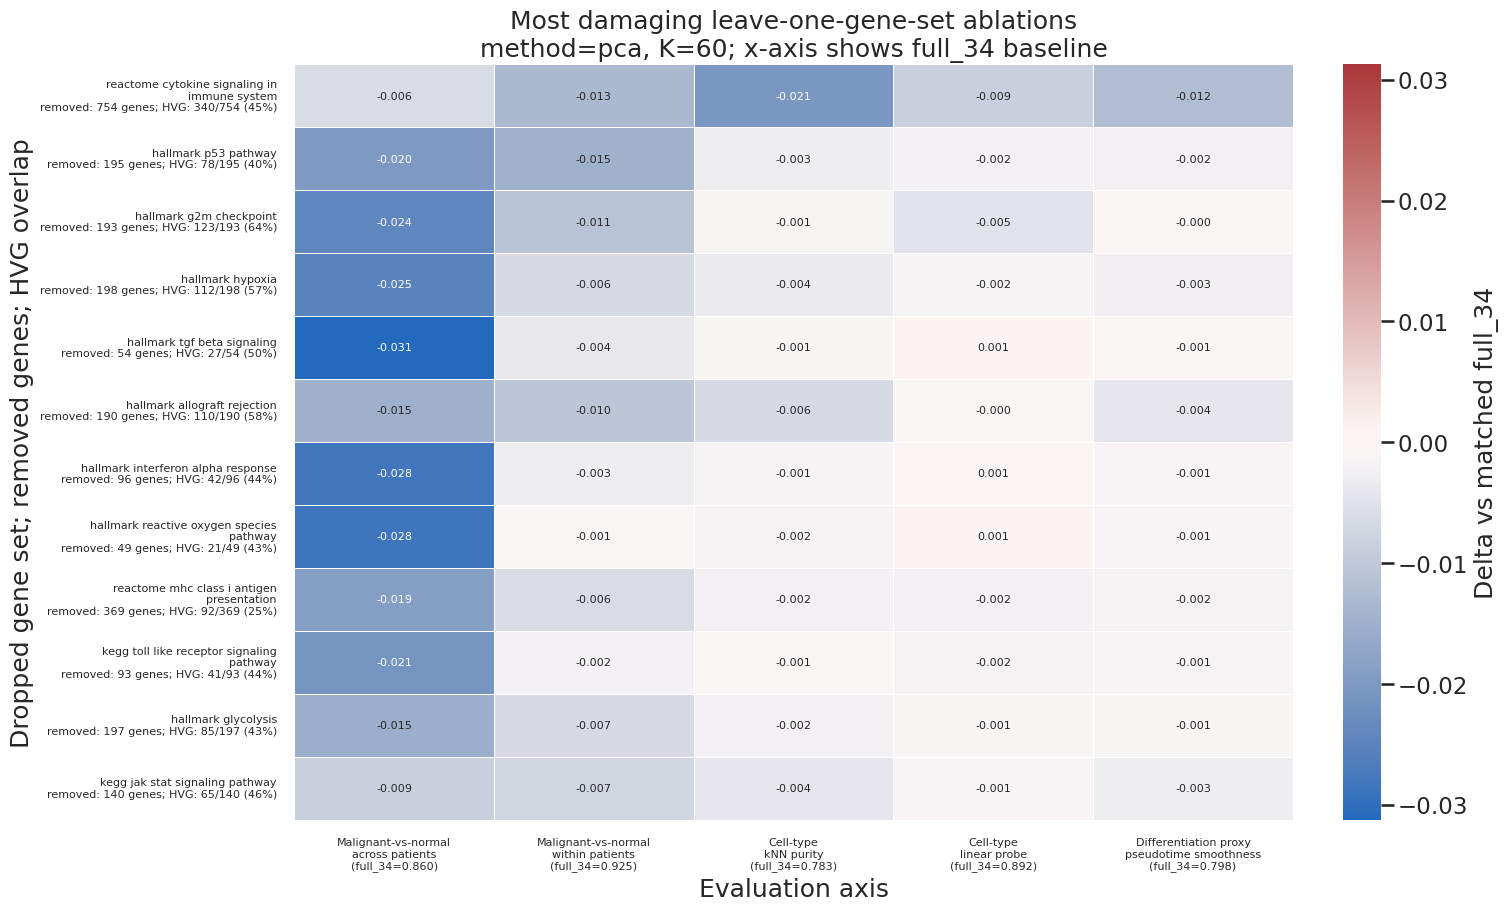

Saved /home/minhang/mds_project/sc_classification/experiments/20260401_023024_plan0_k_sweep_60_none_all_filtered_8f5363e0/analysis/old_geneset_pruning_metrics/focus_mhc_i_ablation_delta_heatmap.png


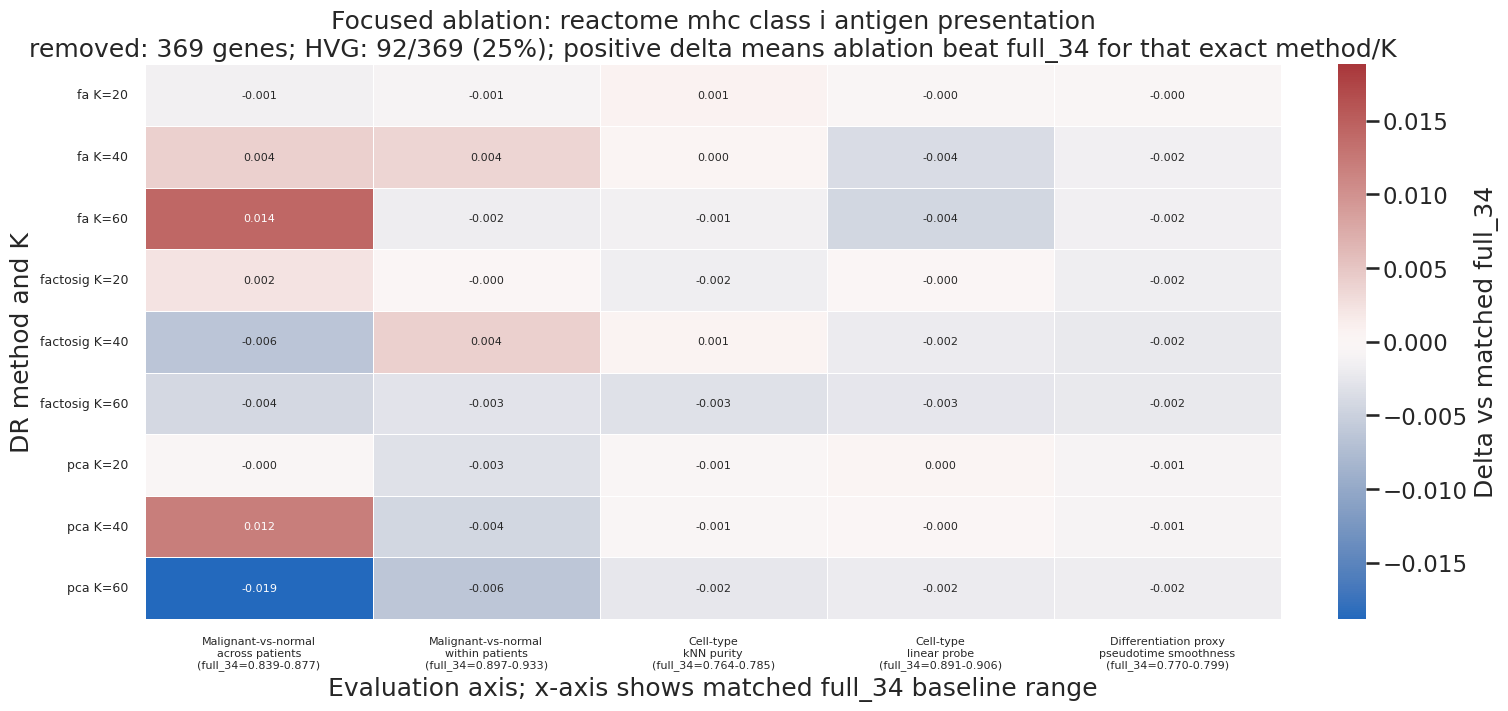

Saved /home/minhang/mds_project/sc_classification/experiments/20260401_023024_plan0_k_sweep_60_none_all_filtered_8f5363e0/analysis/old_geneset_pruning_metrics/full34_method_k_score_heatmap.png


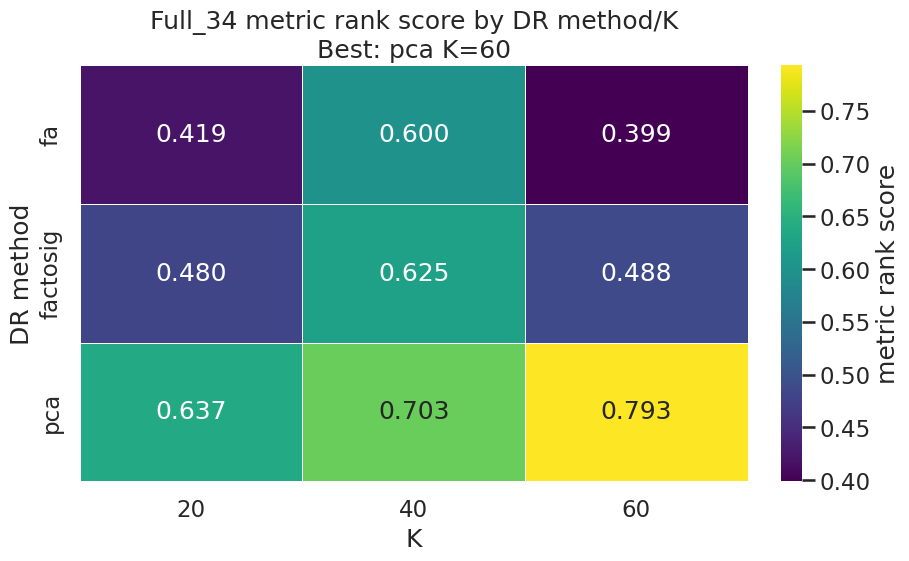

Saved /home/minhang/mds_project/sc_classification/experiments/20260401_023024_plan0_k_sweep_60_none_all_filtered_8f5363e0/analysis/old_geneset_pruning_metrics/pruning_tradeoff_delta_triage_score_fa_k20_one_geneset.png


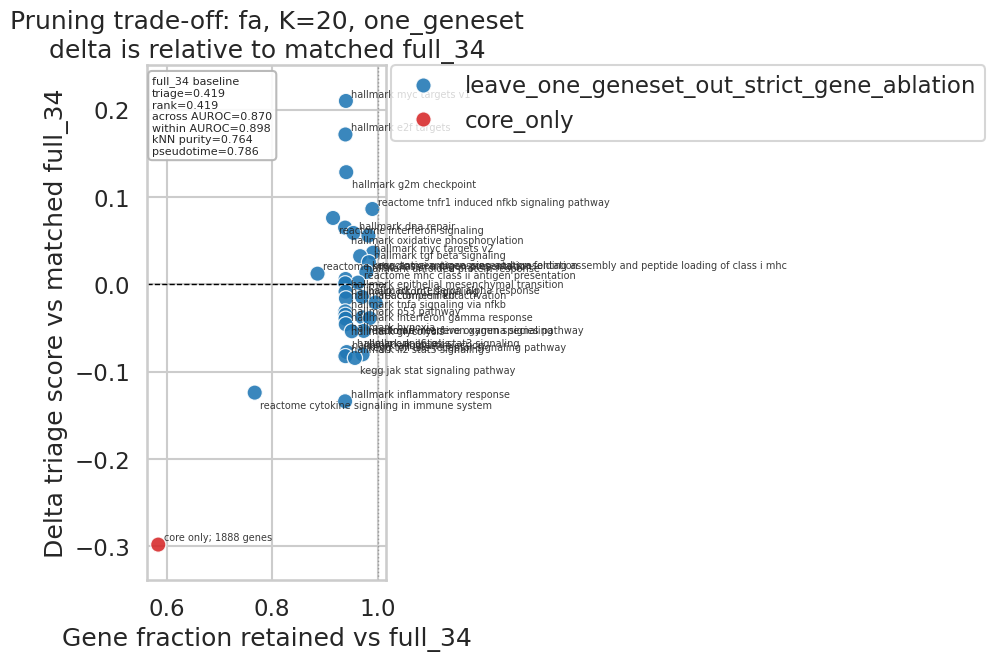

Saved /home/minhang/mds_project/sc_classification/experiments/20260401_023024_plan0_k_sweep_60_none_all_filtered_8f5363e0/analysis/old_geneset_pruning_metrics/pruning_tradeoff_delta_triage_score_fa_k20_group_dropout.png


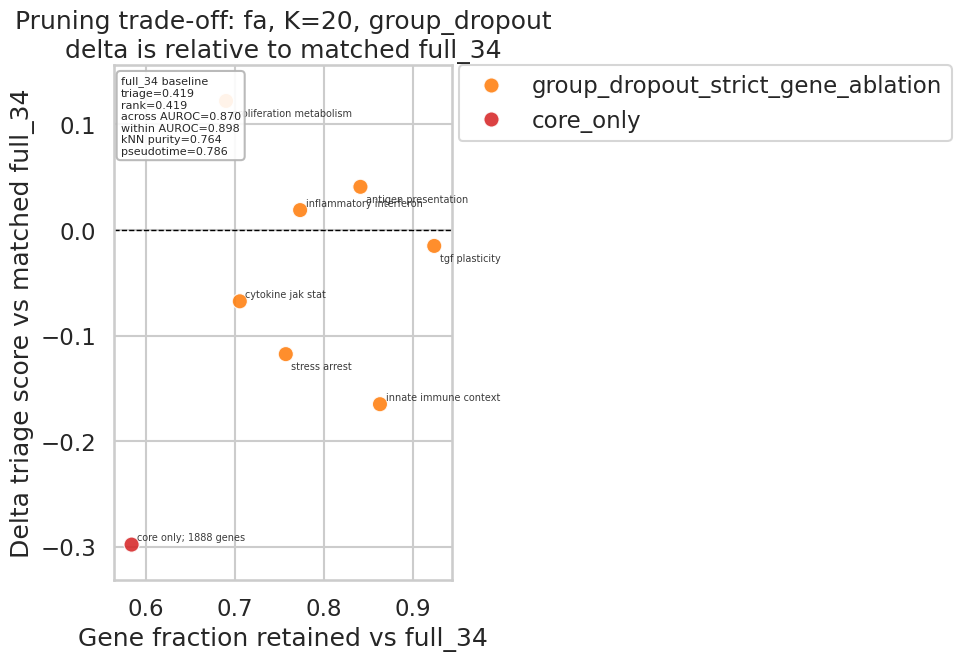

Saved /home/minhang/mds_project/sc_classification/experiments/20260401_023024_plan0_k_sweep_60_none_all_filtered_8f5363e0/analysis/old_geneset_pruning_metrics/pruning_tradeoff_delta_triage_score_fa_k40_one_geneset.png


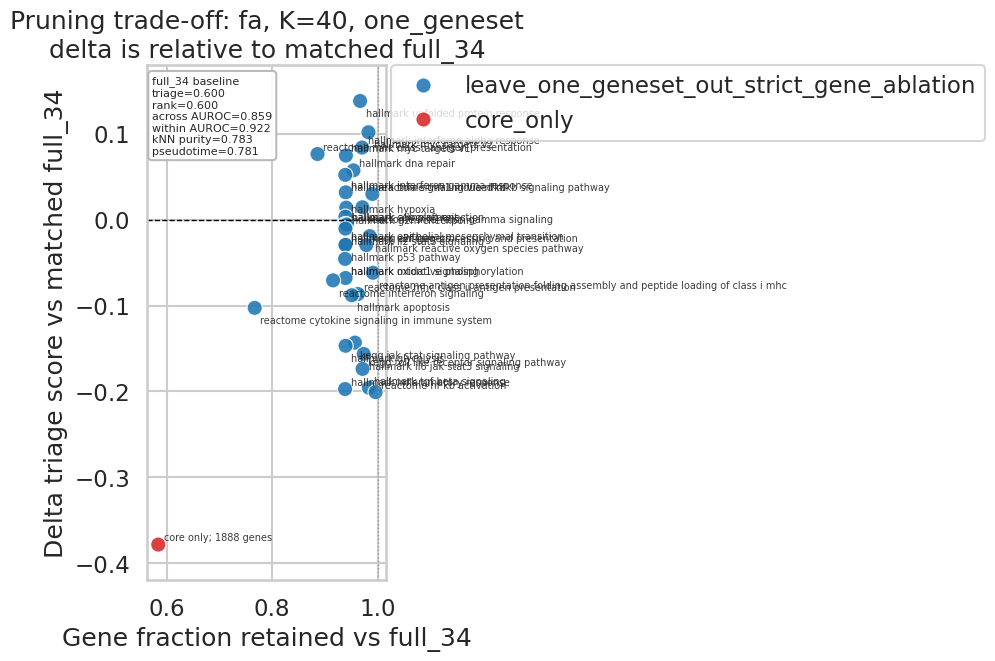

Saved /home/minhang/mds_project/sc_classification/experiments/20260401_023024_plan0_k_sweep_60_none_all_filtered_8f5363e0/analysis/old_geneset_pruning_metrics/pruning_tradeoff_delta_triage_score_fa_k40_group_dropout.png


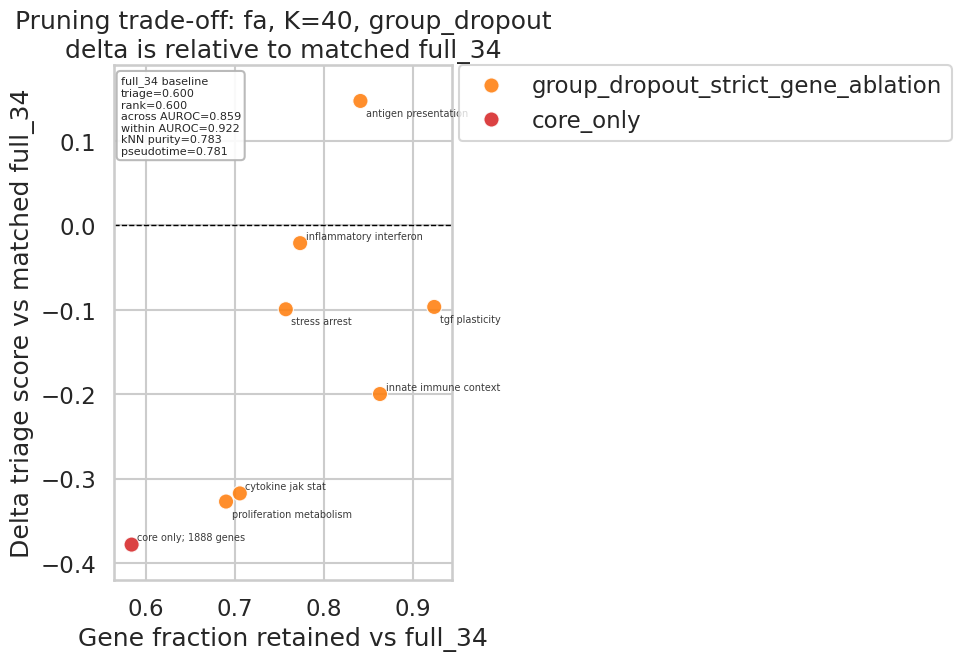

Saved /home/minhang/mds_project/sc_classification/experiments/20260401_023024_plan0_k_sweep_60_none_all_filtered_8f5363e0/analysis/old_geneset_pruning_metrics/pruning_tradeoff_delta_triage_score_fa_k60_one_geneset.png


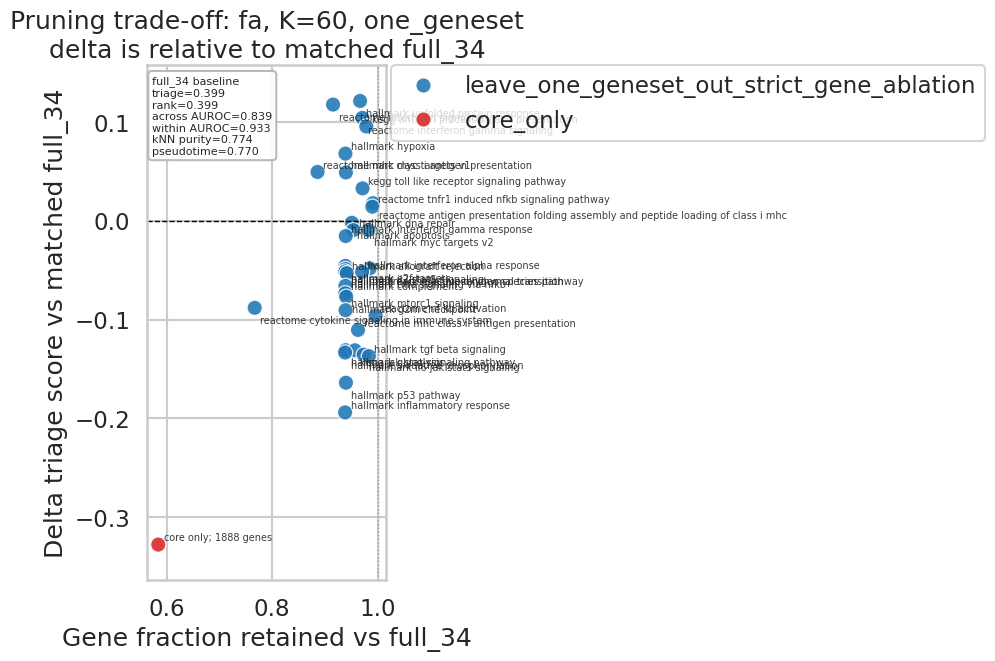

Saved /home/minhang/mds_project/sc_classification/experiments/20260401_023024_plan0_k_sweep_60_none_all_filtered_8f5363e0/analysis/old_geneset_pruning_metrics/pruning_tradeoff_delta_triage_score_fa_k60_group_dropout.png


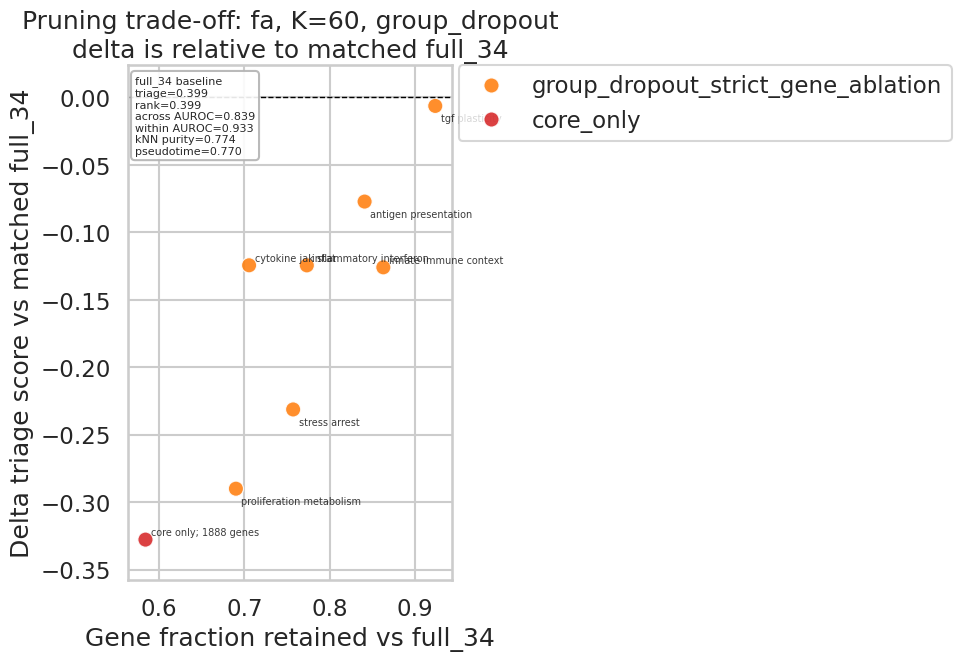

Saved /home/minhang/mds_project/sc_classification/experiments/20260401_023024_plan0_k_sweep_60_none_all_filtered_8f5363e0/analysis/old_geneset_pruning_metrics/pruning_tradeoff_delta_triage_score_factosig_k20_one_geneset.png


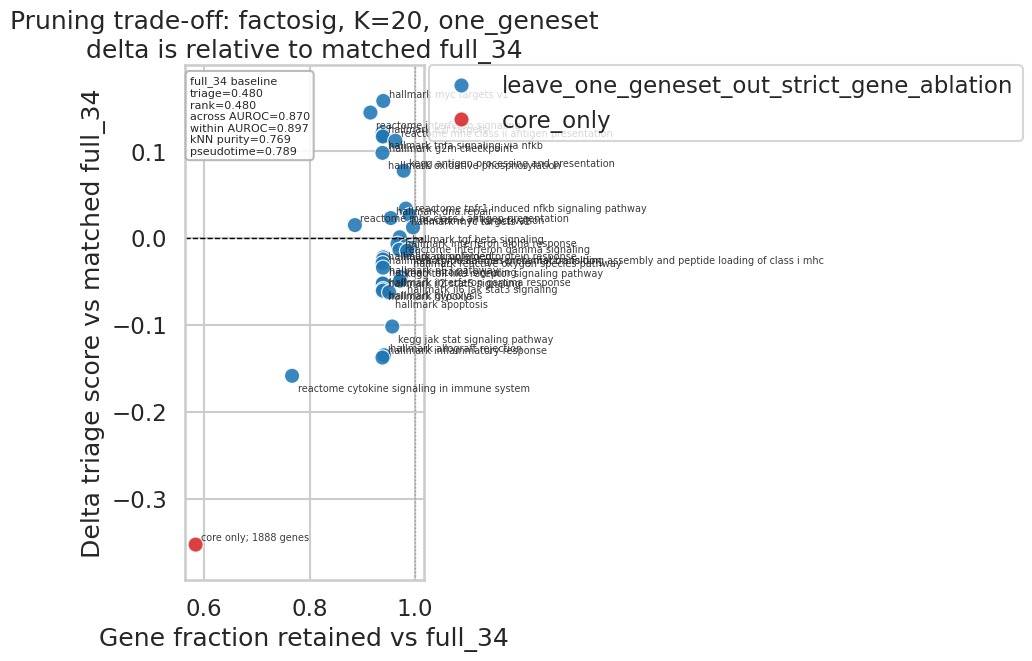

Saved /home/minhang/mds_project/sc_classification/experiments/20260401_023024_plan0_k_sweep_60_none_all_filtered_8f5363e0/analysis/old_geneset_pruning_metrics/pruning_tradeoff_delta_triage_score_factosig_k20_group_dropout.png


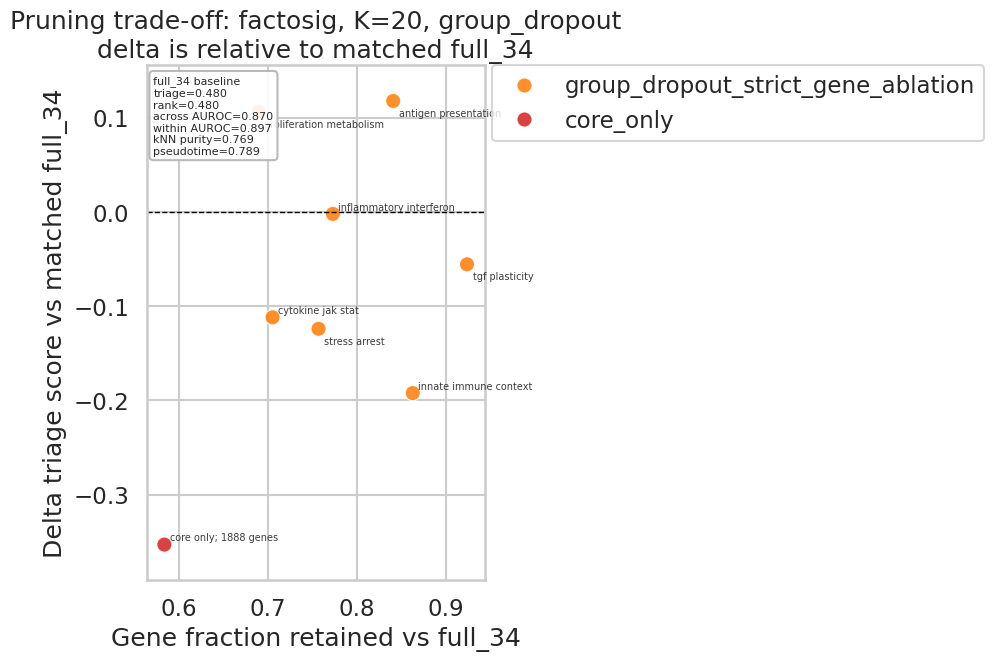

Saved /home/minhang/mds_project/sc_classification/experiments/20260401_023024_plan0_k_sweep_60_none_all_filtered_8f5363e0/analysis/old_geneset_pruning_metrics/pruning_tradeoff_delta_triage_score_factosig_k40_one_geneset.png


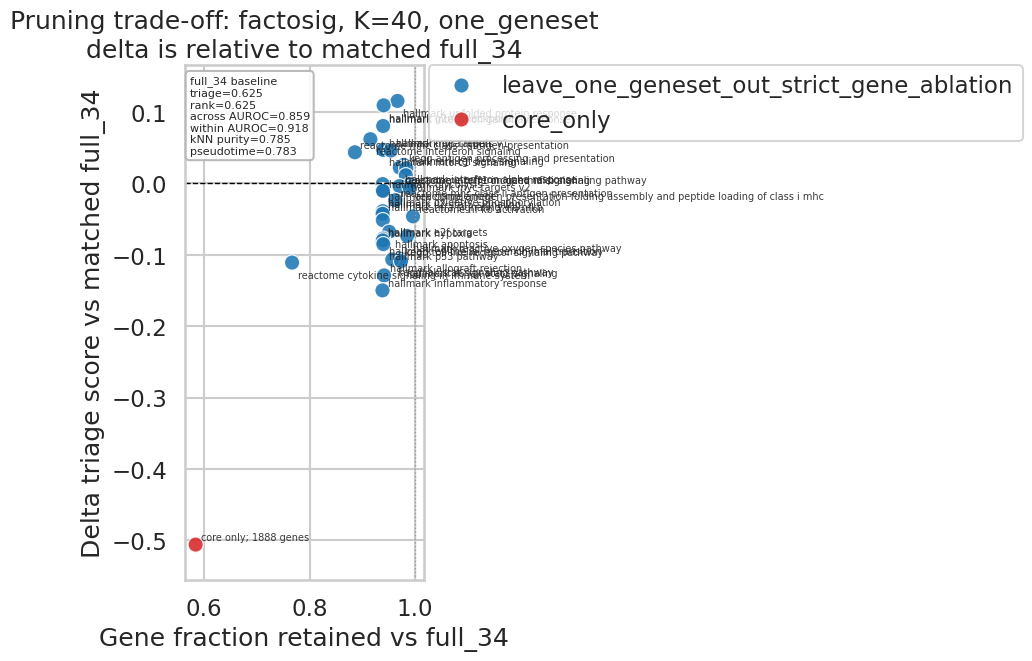

Saved /home/minhang/mds_project/sc_classification/experiments/20260401_023024_plan0_k_sweep_60_none_all_filtered_8f5363e0/analysis/old_geneset_pruning_metrics/pruning_tradeoff_delta_triage_score_factosig_k40_group_dropout.png


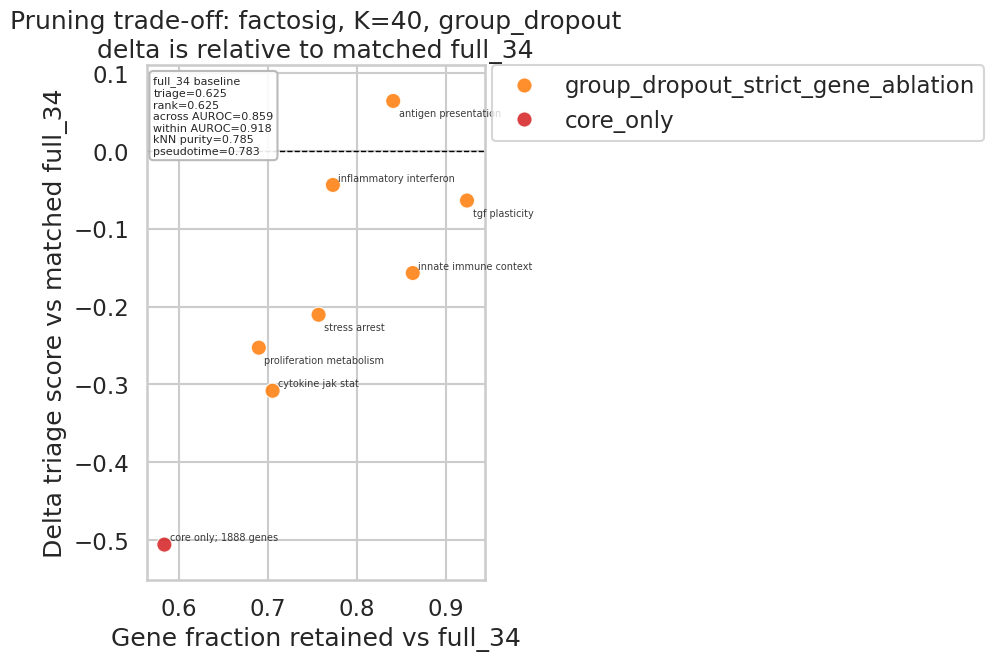

Saved /home/minhang/mds_project/sc_classification/experiments/20260401_023024_plan0_k_sweep_60_none_all_filtered_8f5363e0/analysis/old_geneset_pruning_metrics/pruning_tradeoff_delta_triage_score_factosig_k60_one_geneset.png


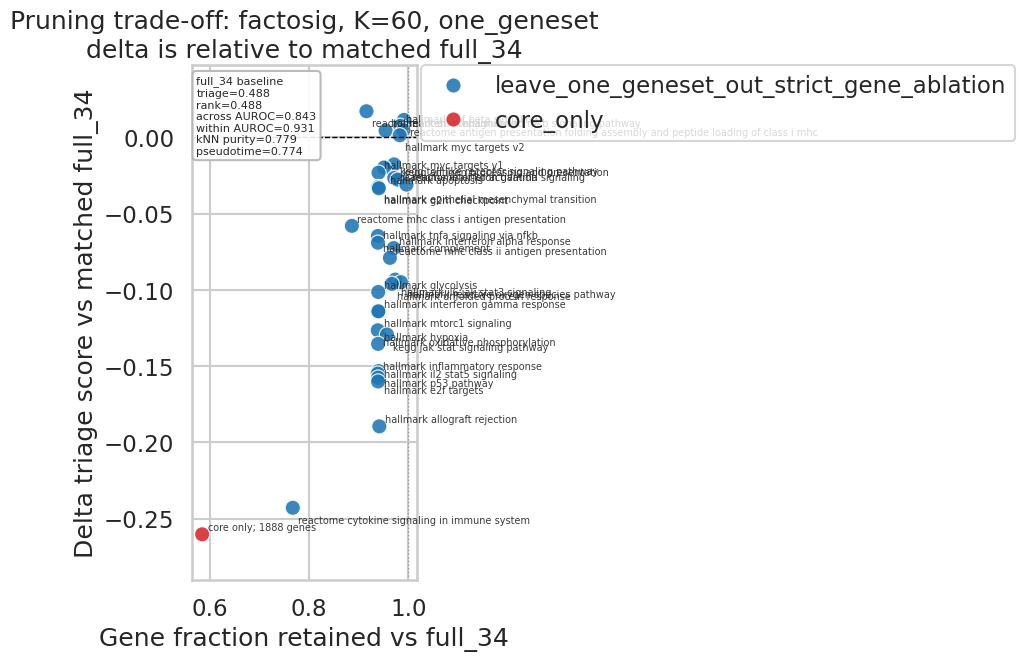

Saved /home/minhang/mds_project/sc_classification/experiments/20260401_023024_plan0_k_sweep_60_none_all_filtered_8f5363e0/analysis/old_geneset_pruning_metrics/pruning_tradeoff_delta_triage_score_factosig_k60_group_dropout.png


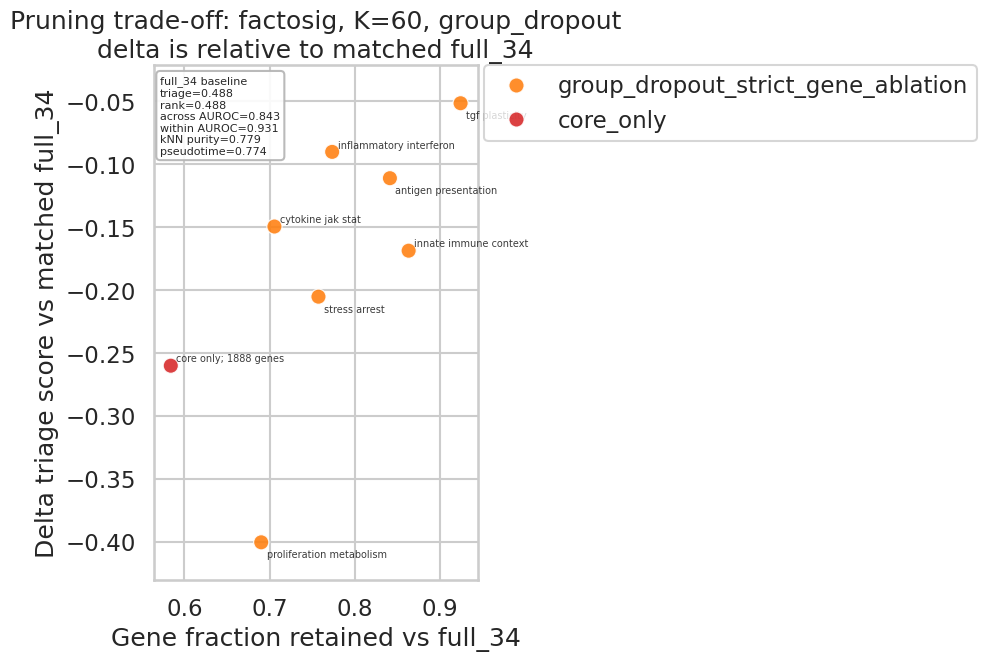

Saved /home/minhang/mds_project/sc_classification/experiments/20260401_023024_plan0_k_sweep_60_none_all_filtered_8f5363e0/analysis/old_geneset_pruning_metrics/pruning_tradeoff_delta_triage_score_pca_k20_one_geneset.png


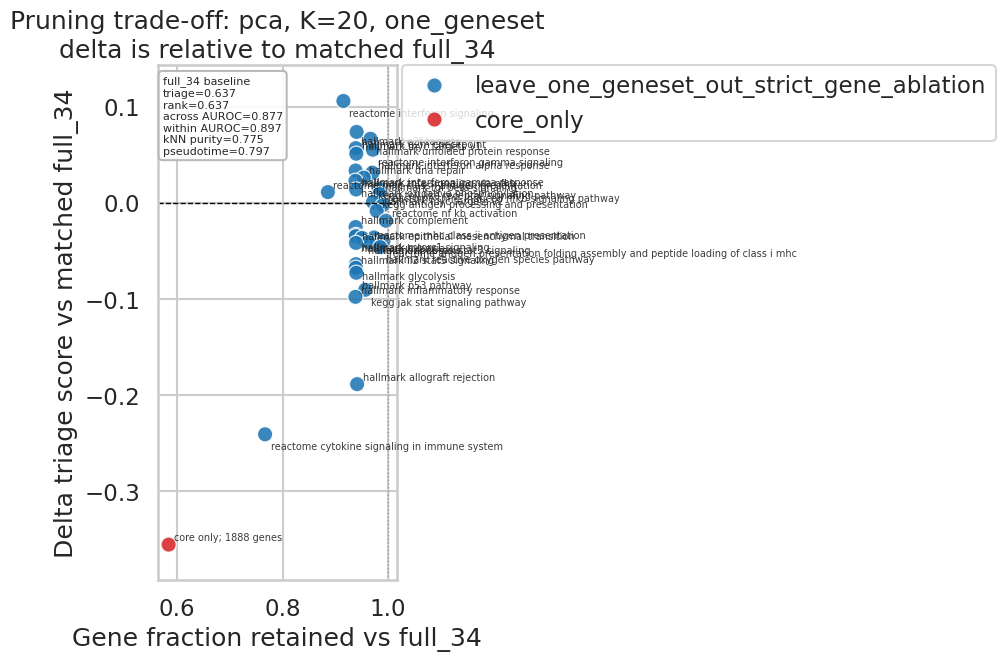

Saved /home/minhang/mds_project/sc_classification/experiments/20260401_023024_plan0_k_sweep_60_none_all_filtered_8f5363e0/analysis/old_geneset_pruning_metrics/pruning_tradeoff_delta_triage_score_pca_k20_group_dropout.png


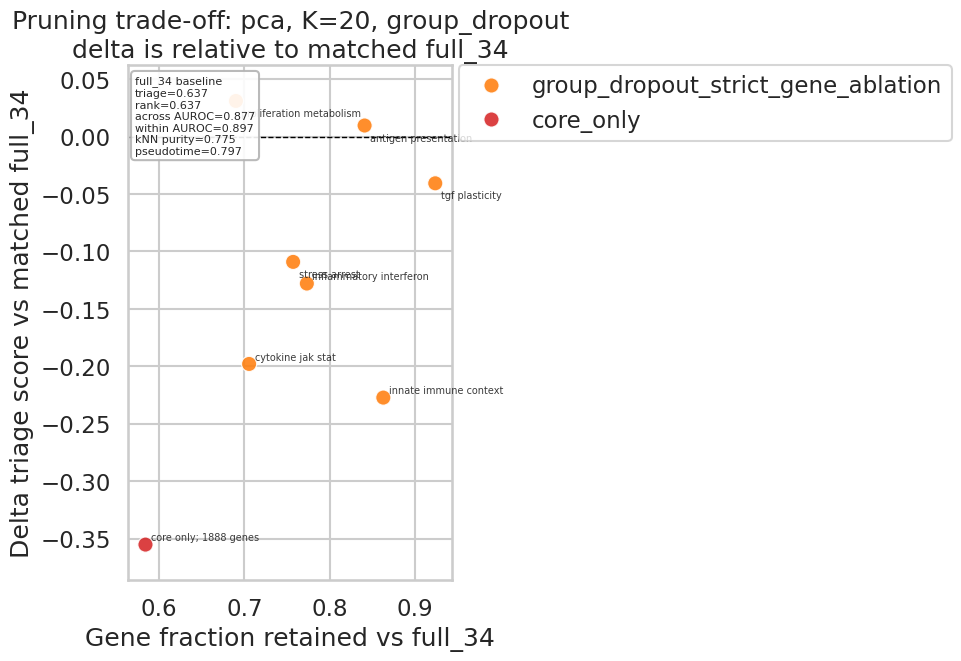

Saved /home/minhang/mds_project/sc_classification/experiments/20260401_023024_plan0_k_sweep_60_none_all_filtered_8f5363e0/analysis/old_geneset_pruning_metrics/pruning_tradeoff_delta_triage_score_pca_k40_one_geneset.png


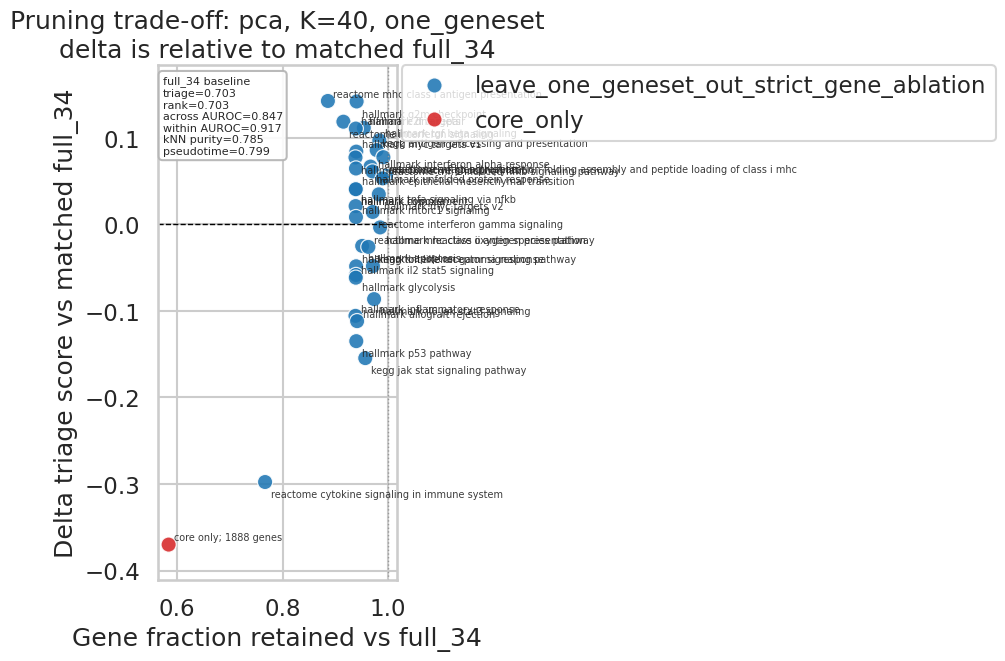

Saved /home/minhang/mds_project/sc_classification/experiments/20260401_023024_plan0_k_sweep_60_none_all_filtered_8f5363e0/analysis/old_geneset_pruning_metrics/pruning_tradeoff_delta_triage_score_pca_k40_group_dropout.png


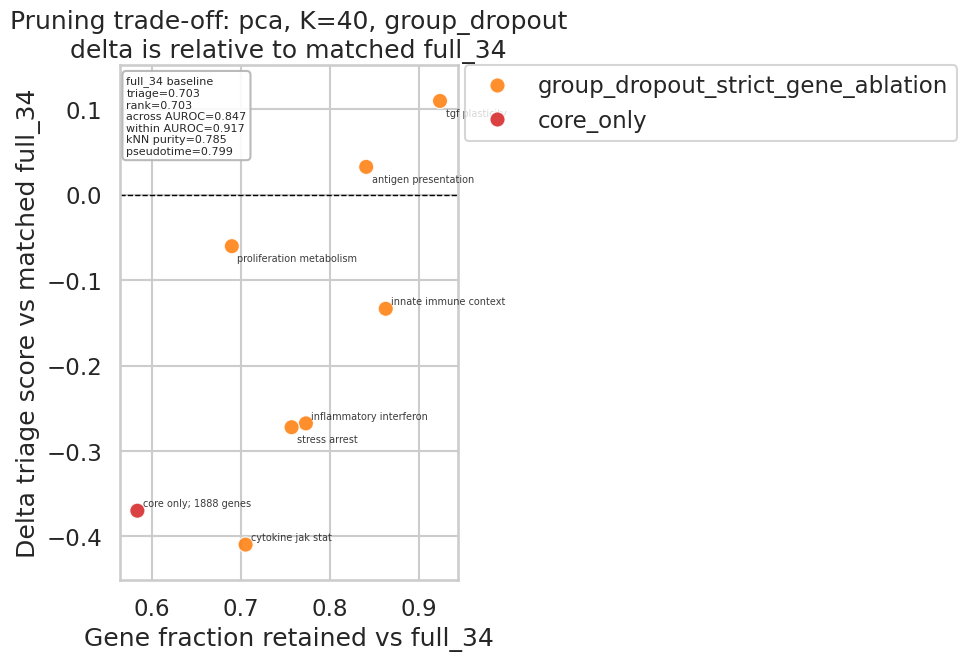

Saved /home/minhang/mds_project/sc_classification/experiments/20260401_023024_plan0_k_sweep_60_none_all_filtered_8f5363e0/analysis/old_geneset_pruning_metrics/pruning_tradeoff_delta_triage_score_pca_k60_one_geneset.png


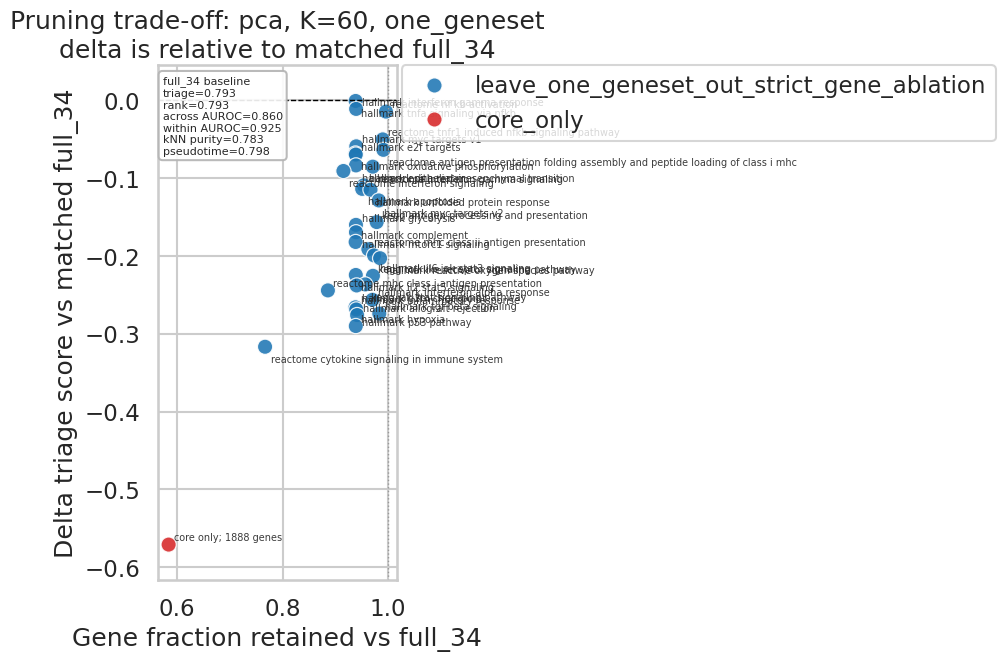

Saved /home/minhang/mds_project/sc_classification/experiments/20260401_023024_plan0_k_sweep_60_none_all_filtered_8f5363e0/analysis/old_geneset_pruning_metrics/pruning_tradeoff_delta_triage_score_pca_k60_group_dropout.png


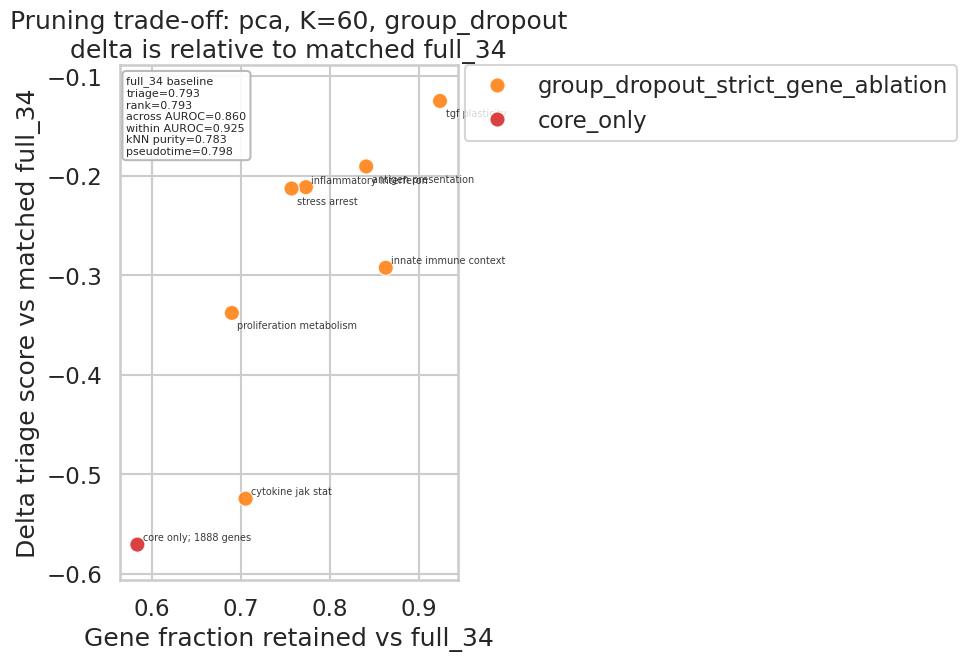

,panel_label,panel_id,panel_type,method,k,n_removed_genes,hvg_removed_n,hvg_removed_fraction,n_shared_genes_removed,gene_fraction_vs_full,delta_triage_score,delta_across_patient_auroc,delta_within_patient_mean_auroc,delta_knn_label_purity_macro,delta_celltype_probe_balanced_accuracy,delta_pseudotime_knn_smoothness
386,core only,core_only,core_only,pca,60,0,0,NaN,0.0,0.583978,-0.570804,-0.028008,-0.020884,-0.043163,-0.019088,-0.025340
376,cytokine jak stat,drop_group__cytokine_jak_stat,group_dropout_strict_gene_ablation,pca,60,952,454,0.476891,617.0,0.705537,-0.524644,-0.015692,-0.006120,-0.033503,-0.014919,-0.021035
392,core only,core_only,core_only,factosig,40,0,0,NaN,0.0,0.583978,-0.505778,-0.020072,0.003542,-0.035927,-0.021732,-0.023455
365,cytokine jak stat,drop_group__cytokine_jak_stat,group_dropout_strict_gene_ablation,pca,40,952,454,0.476891,617.0,0.705537,-0.409745,-0.007652,-0.009845,-0.027934,-0.012253,-0.017301
394,proliferation metabolism,drop_group__proliferation_metabolism,group_dropout_strict_gene_ablation,factosig,60,1002,460,0.459082,307.0,0.690071,-0.400480,-0.034307,-0.009520,-0.016805,0.000707,-0.009331
387,core only,core_only,core_only,fa,40,0,0,NaN,0.0,0.583978,-0.378253,-0.014675,-0.001969,-0.037449,-0.022395,-0.023546
348,core only,core_only,core_only,pca,40,0,0,NaN,0.0,0.583978,-0.370046,-0.001422,-0.003789,-0.038392,-0.020466,-0.022415
371,core only,core_only,core_only,pca,20,0,0,NaN,0.0,0.583978,-0.355210,-0.015250,-0.004746,-0.049595,-0.030015,-0.024842
390,core only,core_only,core_only,factosig,20,0,0,NaN,0.0,0.583978,-0.353001,-0.027414,-0.004275,-0.053467,-0.034831,-0.026851
250,proliferation metabolism,drop_group__proliferation_metabolism,group_dropout_strict_gene_ablation,pca,60,1002,460,0.459082,307.0,0.690071,-0.337980,-0.028376,-0.019338,-0.007643,-0.008133,-0.003783


In [7]:
# Presentation-ready pruning damage plots.
# Negative deltas mean the pruned panel is worse than the matched full_34 control
# evaluated with the same DR method and K.
import ast
import textwrap

FOCUS_PANEL = "drop_geneset__reactome_mhc_class_i_antigen_presentation"
FOCUS_MATCH = "reactome_mhc_class_i_antigen"
DAMAGE_HEATMAP_METHOD = None  # set e.g. "pca" to override; None uses best full_34 score
DAMAGE_HEATMAP_K = None       # set e.g. 60 to override; None uses best full_34 score

PANEL_TYPE_COLORS = {
    "leave_one_geneset_out_strict_gene_ablation": "#1f77b4",
    "group_dropout_strict_gene_ablation": "#ff7f0e",
    "redundancy_pruned": "#2ca02c",
    "core_only": "#d62728",
}

metric_labels = {
    "across_patient_auroc": "Malignant-vs-normal\nacross patients",
    "within_patient_mean_auroc": "Malignant-vs-normal\nwithin patients",
    "knn_label_purity_macro": "Cell-type\nkNN purity",
    "celltype_probe_balanced_accuracy": "Cell-type\nlinear probe",
    "pseudotime_knn_smoothness": "Differentiation proxy\npseudotime smoothness",
}
available_metrics = [m for m in metric_labels if m in leaderboard_df.columns]
score_for_hyperparams = "metric_rank_score" if "metric_rank_score" in leaderboard_df.columns else "triage_score"

with HVG_GENE_LISTS_PATH.open() as f:
    hvg_final_genes = {str(g).upper() for g in json.load(f)["final_gene_set"]}


def clean_panel_label(panel_id: str, width: int = 30) -> str:
    label = str(panel_id)
    for prefix in [
        "drop_geneset__",
        "drop_group__",
        "keep_redundancy_pruned__",
        "redundancy_pruned__",
    ]:
        label = label.replace(prefix, "")
    label = label.replace("_", " ")
    return "\n".join(textwrap.wrap(label, width=width))


def parse_gene_list(value) -> set[str]:
    if value is None:
        return set()
    if isinstance(value, (list, tuple, set)):
        return {str(g).strip().upper() for g in value if str(g).strip()}
    if isinstance(value, float) and pd.isna(value):
        return set()

    text = str(value).strip()
    if not text or text.lower() in {"nan", "none", "[]"}:
        return set()
    try:
        parsed = ast.literal_eval(text)
        if isinstance(parsed, (list, tuple, set)):
            return {str(g).strip().upper() for g in parsed if str(g).strip()}
    except (SyntaxError, ValueError):
        pass

    tokens = text.split(";") if ";" in text else text.split(",")
    return {t.strip().strip("'\"").upper() for t in tokens if t.strip().strip("'\"")}


def add_ablation_gene_metadata(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    excluded_gene_sets = out["excluded_genes"].map(parse_gene_list) if "excluded_genes" in out.columns else [set()] * len(out)
    out["_excluded_gene_set"] = list(excluded_gene_sets)
    n_from_list = out["_excluded_gene_set"].map(len)
    if "n_excluded_genes" in out.columns:
        n_from_col = pd.to_numeric(out["n_excluded_genes"], errors="coerce").fillna(0).astype(int)
        out["n_removed_genes"] = np.where(n_from_col.gt(0), n_from_col, n_from_list)
    else:
        out["n_removed_genes"] = n_from_list
    out["hvg_removed_n"] = out["_excluded_gene_set"].map(lambda genes: len(genes & hvg_final_genes))
    out["hvg_removed_fraction"] = np.where(
        out["n_removed_genes"].gt(0),
        out["hvg_removed_n"] / out["n_removed_genes"],
        np.nan,
    )
    return out


def symmetric_vmax(values, floor: float = 0.01) -> float:
    arr = np.abs(np.asarray(values, dtype=float))
    finite = arr[np.isfinite(arr)]
    return max(float(finite.max()) if finite.size else floor, floor)


def metric_axis_label(metric: str, baseline: float | None = None) -> str:
    label = metric_labels.get(metric, metric.replace("_", " "))
    if baseline is None or not np.isfinite(baseline):
        return label
    return f"{label}\n(full_34={baseline:.3f})"


def metric_axis_label_with_range(metric: str, values: pd.Series) -> str:
    label = metric_labels.get(metric, metric.replace("_", " "))
    vals = pd.to_numeric(values, errors="coerce").dropna()
    if vals.empty:
        return label
    if np.isclose(vals.min(), vals.max()):
        return f"{label}\n(full_34={vals.iloc[0]:.3f})"
    return f"{label}\n(full_34={vals.min():.3f}-{vals.max():.3f})"


def save_and_show(fig, filename: str) -> None:
    out_path = OUT_DIR / filename
    fig.savefig(out_path, dpi=200, bbox_inches="tight")
    print(f"Saved {out_path}")
    plt.show()


if leaderboard_df.empty:
    print("No leaderboard rows to plot.")
else:
    plot_df = leaderboard_df.loc[leaderboard_df["status"].eq("ok")].copy()
    if plot_df.empty:
        print("No successful leaderboard rows to plot.")
    else:
        control_cols = [
            "method",
            "k",
            "triage_score",
            score_for_hyperparams,
            *available_metrics,
        ]
        control_cols = list(dict.fromkeys(control_cols))
        controls = (
            plot_df.loc[plot_df["panel_type"].eq("full_control"), control_cols]
            .drop_duplicates(["method", "k"])
        )
        delta_df = plot_df.merge(
            controls,
            on=["method", "k"],
            how="left",
            suffixes=("", "_full"),
        )

        for metric in available_metrics:
            delta_df[f"delta_{metric}"] = delta_df[metric] - delta_df[f"{metric}_full"]
        delta_df["delta_triage_score"] = delta_df["triage_score"] - delta_df["triage_score_full"]
        delta_cols = [f"delta_{m}" for m in available_metrics]

        delta_df = add_ablation_gene_metadata(delta_df)
        damage_df = delta_df.loc[~delta_df["panel_type"].eq("full_control")].copy()
        leave_one_df = damage_df.loc[
            damage_df["panel_type"].eq("leave_one_geneset_out_strict_gene_ablation")
        ].copy()

        control_df_all = plot_df.loc[plot_df["panel_type"].eq("full_control")].copy()
        if DAMAGE_HEATMAP_METHOD is None or DAMAGE_HEATMAP_K is None:
            damage_baseline_row = control_df_all.sort_values(score_for_hyperparams, ascending=False).iloc[0]
            selected_damage_method = str(damage_baseline_row["method"])
            selected_damage_k = int(damage_baseline_row["k"])
        else:
            selected_damage_method = str(DAMAGE_HEATMAP_METHOD)
            selected_damage_k = int(DAMAGE_HEATMAP_K)
            damage_baseline = control_df_all.loc[
                control_df_all["method"].astype(str).eq(selected_damage_method)
                & control_df_all["k"].astype(int).eq(selected_damage_k)
            ]
            if damage_baseline.empty:
                raise ValueError(f"No full_34 row for method={selected_damage_method}, K={selected_damage_k}")
            damage_baseline_row = damage_baseline.iloc[0]
        damage_baselines = {m: float(damage_baseline_row[m]) for m in available_metrics if m in damage_baseline_row}

        # Plot 1: most damaging single-gene-set ablations, annotated with genes removed and HVG overlap.
        leave_one_for_heatmap = leave_one_df.loc[
            leave_one_df["method"].astype(str).eq(selected_damage_method)
            & leave_one_df["k"].astype(int).eq(selected_damage_k)
        ].copy()
        if leave_one_for_heatmap.empty or not delta_cols:
            print(f"No leave-one-gene-set ablations found for method={selected_damage_method}, K={selected_damage_k}.")
        else:
            worst_by_panel = leave_one_for_heatmap.groupby("panel_id")[delta_cols].min()
            leave_one_meta = leave_one_for_heatmap.groupby("panel_id").agg(
                n_removed_genes=("n_removed_genes", "max"),
                hvg_removed_n=("hvg_removed_n", "max"),
                hvg_removed_fraction=("hvg_removed_fraction", "max"),
                n_shared_genes_removed=("n_shared_genes_removed", "max"),
            )
            worst_by_panel = worst_by_panel.join(leave_one_meta)
            worst_by_panel["damage_score"] = worst_by_panel[delta_cols].clip(upper=0).sum(axis=1)
            top_damage_ids = worst_by_panel.nsmallest(12, "damage_score").index
            heatmap_data = worst_by_panel.loc[top_damage_ids, delta_cols]
            heatmap_data.index = [
                (
                    f"{clean_panel_label(panel_id, width=34)}\n"
                    f"removed: {int(worst_by_panel.loc[panel_id, 'n_removed_genes'])} genes; "
                    f"HVG: {int(worst_by_panel.loc[panel_id, 'hvg_removed_n'])}/"
                    f"{int(worst_by_panel.loc[panel_id, 'n_removed_genes'])} "
                    f"({worst_by_panel.loc[panel_id, 'hvg_removed_fraction']:.0%})"
                )
                for panel_id in top_damage_ids
            ]
            heatmap_data.columns = [
                metric_axis_label(c.replace("delta_", ""), damage_baselines.get(c.replace("delta_", "")))
                for c in heatmap_data.columns
            ]

            fig, ax = plt.subplots(figsize=(15, 9), constrained_layout=True)
            sns.heatmap(
                heatmap_data,
                cmap="vlag",
                center=0,
                vmin=-symmetric_vmax(heatmap_data.to_numpy()),
                vmax=symmetric_vmax(heatmap_data.to_numpy()),
                annot=True,
                fmt=".3f",
                annot_kws={"fontsize": 8},
                linewidths=0.5,
                cbar_kws={"label": "Delta vs matched full_34"},
                ax=ax,
            )
            ax.set_title(
                f"Most damaging leave-one-gene-set ablations\n"
                f"method={selected_damage_method}, K={selected_damage_k}; x-axis shows full_34 baseline"
            )
            ax.set_xlabel("Evaluation axis")
            ax.set_ylabel("Dropped gene set; removed genes; HVG overlap")
            ax.tick_params(axis="x", labelsize=8, rotation=0)
            ax.tick_params(axis="y", labelsize=8)
            save_and_show(fig, "leave_one_geneset_damage_heatmap.png")

        # Plot 2: focused MHC-I ablation across DR method and K.
        focus_panel = FOCUS_PANEL
        if focus_panel not in set(delta_df["panel_id"]):
            matches = sorted(p for p in delta_df["panel_id"].dropna().unique() if FOCUS_MATCH in str(p))
            focus_panel = matches[0] if matches else FOCUS_PANEL
        focus_df = delta_df.loc[delta_df["panel_id"].eq(focus_panel)].copy()
        if focus_df.empty or not delta_cols:
            print(f"No rows found for {FOCUS_MATCH}.")
        else:
            focus_df = focus_df.sort_values(["method", "k"])
            focus_matrix = focus_df.assign(method_k=focus_df["method"] + " K=" + focus_df["k"].astype(str))
            focus_matrix = focus_matrix.set_index("method_k")[delta_cols]
            focus_matrix.columns = [
                metric_axis_label_with_range(c.replace("delta_", ""), focus_df[f"{c.replace('delta_', '')}_full"])
                for c in focus_matrix.columns
            ]
            focus_meta = focus_df.iloc[0]
            focus_removed = int(focus_meta["n_removed_genes"])
            focus_hvg_n = int(focus_meta["hvg_removed_n"])
            focus_hvg_frac = focus_meta["hvg_removed_fraction"]

            fig, ax = plt.subplots(figsize=(15, 7), constrained_layout=True)
            sns.heatmap(
                focus_matrix,
                cmap="vlag",
                center=0,
                vmin=-symmetric_vmax(focus_matrix.to_numpy()),
                vmax=symmetric_vmax(focus_matrix.to_numpy()),
                annot=True,
                fmt=".3f",
                annot_kws={"fontsize": 8},
                linewidths=0.5,
                cbar_kws={"label": "Delta vs matched full_34"},
                ax=ax,
            )
            ax.set_title(
                f"Focused ablation: {clean_panel_label(focus_panel, width=70).replace(chr(10), ' ')}\n"
                f"removed: {focus_removed} genes; HVG: {focus_hvg_n}/{focus_removed} ({focus_hvg_frac:.0%}); "
                "positive delta means ablation beat full_34 for that exact method/K"
            )
            ax.set_xlabel("Evaluation axis; x-axis shows matched full_34 baseline range")
            ax.set_ylabel("DR method and K")
            ax.tick_params(axis="x", labelsize=8, rotation=0)
            ax.tick_params(axis="y", labelsize=9)
            save_and_show(fig, "focus_mhc_i_ablation_delta_heatmap.png")

        # Plot 3: which full_34 DR method/K setting is strongest before pruning?
        control_df = plot_df.loc[plot_df["panel_type"].eq("full_control")].copy()
        if control_df.empty:
            print("No full_34 control rows found.")
        else:
            hyper_grid = control_df.pivot_table(
                index="method",
                columns="k",
                values=score_for_hyperparams,
                aggfunc="max",
            ).sort_index()
            best_control = control_df.sort_values(score_for_hyperparams, ascending=False).iloc[0]

            fig, ax = plt.subplots(figsize=(9, 5.5), constrained_layout=True)
            sns.heatmap(
                hyper_grid,
                annot=True,
                fmt=".3f",
                cmap="viridis",
                linewidths=0.5,
                cbar_kws={"label": score_for_hyperparams.replace("_", " ")},
                ax=ax,
            )
            ax.set_title(
                f"Full_34 {score_for_hyperparams.replace('_', ' ')} by DR method/K\n"
                f"Best: {best_control['method']} K={int(best_control['k'])}"
            )
            ax.set_xlabel("K")
            ax.set_ylabel("DR method")
            save_and_show(fig, "full34_method_k_score_heatmap.png")

        # Plot 4: pruning trade-off view as a reusable method/K/ablation-group function.
        ABLATION_GROUP_TO_PANEL_TYPE = {
            "one_geneset": "leave_one_geneset_out_strict_gene_ablation",
            "group_dropout": "group_dropout_strict_gene_ablation",
        }

        def full34_baseline_label(control_row: pd.Series) -> str:
            parts = [
                f"full_34 baseline",
                f"triage={control_row['triage_score']:.3f}",
            ]
            if "metric_rank_score" in control_row:
                parts.append(f"rank={control_row['metric_rank_score']:.3f}")
            for metric, short_label in [
                ("across_patient_auroc", "across AUROC"),
                ("within_patient_mean_auroc", "within AUROC"),
                ("knn_label_purity_macro", "kNN purity"),
                ("pseudotime_knn_smoothness", "pseudotime"),
            ]:
                if metric in control_row and pd.notna(control_row[metric]):
                    parts.append(f"{short_label}={control_row[metric]:.3f}")
            return "\n".join(parts)

        def plot_pruning_tradeoff(
            delta_table: pd.DataFrame,
            dr_method: str,
            k: int,
            ablation_group: str = "one_geneset",
            *,
            include_core_only: bool = True,
            include_redundancy_pruned: bool | str = "auto",
            annotate_top_n: int | None = None,
            annotate_all: bool = True,
            output_filename: str | None = None,
            show: bool = True,
        ) -> dict[str, object]:
            """Plot pruning trade-off for one DR method, K, and ablation family."""
            if ablation_group not in ABLATION_GROUP_TO_PANEL_TYPE:
                raise ValueError(f"ablation_group must be one of {sorted(ABLATION_GROUP_TO_PANEL_TYPE)}")
            dr_method = str(dr_method)
            k = int(k)
            target_panel_type = ABLATION_GROUP_TO_PANEL_TYPE[ablation_group]

            method_k_df = delta_table.loc[
                delta_table["method"].astype(str).eq(dr_method)
                & delta_table["k"].astype(int).eq(k)
            ].copy()
            if method_k_df.empty:
                raise ValueError(f"No rows found for method={dr_method}, K={k}")

            control = method_k_df.loc[method_k_df["panel_type"].eq("full_control")]
            if control.empty:
                raise ValueError(f"No full_34 row found for method={dr_method}, K={k}")
            control_row = control.iloc[0]

            panel_types = [target_panel_type]
            if include_core_only:
                panel_types.append("core_only")
            if include_redundancy_pruned:
                redundancy = method_k_df.loc[method_k_df["panel_type"].eq("redundancy_pruned")]
                if include_redundancy_pruned == "auto":
                    # If redundancy pruning retains the full gene set, it is equivalent for this gene-fraction trade-off.
                    keep_redundancy = (
                        not redundancy.empty
                        and not np.isclose(redundancy["gene_fraction_vs_full"].astype(float), 1.0).all()
                    )
                else:
                    keep_redundancy = True
                if keep_redundancy:
                    panel_types.append("redundancy_pruned")

            plot_data = method_k_df.loc[method_k_df["panel_type"].isin(panel_types)].copy()
            if plot_data.empty:
                raise ValueError(f"No plot rows for method={dr_method}, K={k}, ablation_group={ablation_group}")

            fig, ax = plt.subplots(figsize=(9.5, 6.5), constrained_layout=True)
            hue_order = [p for p in PANEL_TYPE_COLORS if p in plot_data["panel_type"].unique()]
            sns.scatterplot(
                data=plot_data,
                x="gene_fraction_vs_full",
                y="delta_triage_score",
                hue="panel_type",
                hue_order=hue_order,
                palette=PANEL_TYPE_COLORS,
                s=120,
                alpha=0.88,
                ax=ax,
            )
            ax.axhline(0, color="black", linewidth=1, linestyle="--")
            ax.axvline(1, color="0.6", linewidth=1, linestyle=":")
            ax.set_title(
                f"Pruning trade-off: {dr_method}, K={k}, {ablation_group}\n"
                "delta is relative to matched full_34"
            )
            ax.set_xlabel("Gene fraction retained vs full_34")
            ax.set_ylabel("Delta triage score vs matched full_34")

            x_pad = max(0.02, 0.05 * (plot_data["gene_fraction_vs_full"].max() - plot_data["gene_fraction_vs_full"].min() + 1e-9))
            y_pad = max(0.03, 0.08 * (plot_data["delta_triage_score"].max() - plot_data["delta_triage_score"].min() + 1e-9))
            ax.set_xlim(max(0, plot_data["gene_fraction_vs_full"].min() - x_pad), min(1.03, plot_data["gene_fraction_vs_full"].max() + x_pad))
            ax.set_ylim(plot_data["delta_triage_score"].min() - y_pad, plot_data["delta_triage_score"].max() + y_pad)

            if annotate_all:
                label_rows = plot_data.copy()
            else:
                label_rows = plot_data.loc[plot_data["panel_type"].eq(target_panel_type)].nsmallest(
                    annotate_top_n or 0,
                    "delta_triage_score",
                )
                special_rows = plot_data.loc[plot_data["panel_type"].eq("core_only")].drop_duplicates("panel_id")
                label_rows = pd.concat([label_rows, special_rows], ignore_index=True).drop_duplicates("panel_id")

            label_rows = label_rows.sort_values(["gene_fraction_vs_full", "delta_triage_score", "panel_id"])
            for i, (_, row) in enumerate(label_rows.iterrows()):
                label = clean_panel_label(row["panel_id"], width=20).replace("\n", " ")
                if row["panel_type"] == "core_only":
                    label = f"{label}; {int(row['n_genes'])} genes"
                elif row["panel_type"] == "redundancy_pruned":
                    label = f"{label}; {int(row['n_genes'])} genes"
                offset_y = 5 if i % 2 == 0 else -9
                ax.annotate(
                    label,
                    xy=(row["gene_fraction_vs_full"], row["delta_triage_score"]),
                    xytext=(4, offset_y),
                    textcoords="offset points",
                    fontsize=7,
                    ha="left",
                    va="center",
                    alpha=0.9,
                )

            ax.text(
                0.02,
                0.98,
                full34_baseline_label(control_row),
                transform=ax.transAxes,
                ha="left",
                va="top",
                fontsize=8,
                bbox={"boxstyle": "round,pad=0.35", "facecolor": "white", "edgecolor": "0.7", "alpha": 0.9},
            )
            ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)

            if output_filename is None:
                output_filename = f"pruning_tradeoff_delta_triage_score_{dr_method}_k{k}_{ablation_group}.png"
            out_path = OUT_DIR / output_filename
            fig.savefig(out_path, dpi=200, bbox_inches="tight")
            print(f"Saved {out_path}")
            if show:
                plt.show()
            else:
                plt.close(fig)
            return {"fig": fig, "ax": ax, "plot_data": plot_data, "method": dr_method, "k": k, "ablation_group": ablation_group}

        # Example loop: generate every method x K x ablation-group configuration.
        tradeoff_results = []
        for method in sorted(damage_df["method"].dropna().astype(str).unique()):
            for k_value in sorted(damage_df.loc[damage_df["method"].astype(str).eq(method), "k"].dropna().astype(int).unique()):
                for ablation_group in ["one_geneset", "group_dropout"]:
                    try:
                        tradeoff_results.append(
                            plot_pruning_tradeoff(
                                delta_df,
                                dr_method=method,
                                k=k_value,
                                ablation_group=ablation_group,
                                include_core_only=True,
                                include_redundancy_pruned="auto",
                                annotate_all=True,
                            )
                        )
                    except ValueError as exc:
                        print(f"Skipping {method} K={k_value} {ablation_group}: {exc}")

        damage_table_cols = [
            "panel_id",
            "panel_type",
            "method",
            "k",
            "n_removed_genes",
            "hvg_removed_n",
            "hvg_removed_fraction",
            "n_shared_genes_removed",
            "gene_fraction_vs_full",
            "delta_triage_score",
            *delta_cols,
        ]
        damage_table_cols = [c for c in damage_table_cols if c in damage_df.columns]
        damage_table = damage_df.sort_values("delta_triage_score")[damage_table_cols].head(15).copy()
        damage_table.insert(
            0,
            "panel_label",
            damage_table["panel_id"].map(lambda x: clean_panel_label(x, width=60).replace("\n", " ")),
        )
        display(damage_table)

### Scoring and Panel-Type Glossary

- `metric_rank_score` is the mean percentile rank across four metrics in the successful leaderboard rows: across-patient AUROC, across-patient AUPRC, cell-type kNN purity, and pseudotime kNN smoothness. Higher means the panel/method/K setting ranks better across these biological geometry checks.
- `triage_score = metric_rank_score + 0.15 * parsimony_bonus`, where `parsimony_bonus = 1 - gene_fraction_vs_full`. It therefore rewards good metric rank first, then gives a small bonus to smaller panels.
- `group_dropout_strict_gene_ablation` removes all gene sets in one manifest biology group, then also removes the dropped group's genes even if those genes appear in retained gene sets. This asks whether a broad biological program is required.
- `leave_one_geneset_out_strict_gene_ablation` removes one gene set and strictly removes its covered genes even when shared with other retained sets. This asks whether a specific gene set is essential.
- `redundancy_pruned` keeps all Core gene sets and greedily removes Optional gene sets whose covered-gene Jaccard overlap with an already kept set exceeds the threshold. This asks whether redundant optional gene sets can be dropped without damaging geometry.
- `core_only` keeps only manifest-priority Core gene sets. This asks whether the curated required biology is sufficient without Optional sets.

For presentation, the most interpretable claim is usually a matched-control delta: at the same DR method and K, does removing a gene set reduce malignant/normal separation, cell-type neighborhood purity, or pseudotime smoothness compared with `full_34`?

### Slide Formula: Triage Score

For each evaluated row \((panel, method, K)\), four core metrics are converted into percentile ranks across all successful rows:

\[
R_m(i) = \mathrm{percentile\_rank}(x_{i,m})
\]

where higher is better and \(m\) is one of:

- across-patient malignant-vs-normal AUROC
- across-patient malignant-vs-normal AUPRC
- cell-type kNN purity macro
- pseudotime kNN smoothness

The geometry score is the mean of those percentile ranks:

\[
\mathrm{metric\_rank\_score}_i = \frac{1}{4}\sum_m R_m(i)
\]

The size bonus rewards panels that use fewer genes than the matched `full_34` panel:

\[
\mathrm{parsimony\_bonus}_i = 1 - \min\left(\frac{n\_genes_i}{n\_genes_{full\_34}}, 1\right)
\]

The final triage score is:

\[
\mathrm{triage\_score}_i = \mathrm{metric\_rank\_score}_i + 0.15 \times \mathrm{parsimony\_bonus}_i
\]

In the trade-off plots, the y-axis is:

\[
\Delta \mathrm{triage\_score}_i = \mathrm{triage\_score}_i - \mathrm{triage\_score}_{full\_34,\ same\ method,K}
\]

Negative values mean the pruned panel performs worse than its matched `full_34` control; positive values mean it outperformed the matched control for that method/K under this composite score.

### How to Read These Metrics

- `Malignant-vs-normal across patients`: logistic regression on latent DR coordinates with `patient` held out by `GroupKFold`. This is a patient-generalization test. The baseline shown in parentheses or as `full_34=` is the matched `full_34` score before ablation.
- `Cell-type kNN purity`: for each cell, find nearest neighbors in latent space and ask what fraction share the same `predicted.annotation`; the reported macro score averages per-cell-type purity so abundant cell types do not dominate.
- `Cell-type linear probe`: cross-validated logistic regression predicts `predicted.annotation` from the latent coordinates. High values mean cell type is linearly decodable from the embedding, not just locally clustered.
- `Differentiation proxy pseudotime smoothness`: compares pseudotime differences among latent nearest neighbors against random cell pairs. Higher means nearby cells in latent space tend to have similar `predicted.pseudotime`.
- Positive ablation deltas can happen because a smaller panel can remove noisy/redundant genes for a specific method/K/metric. Treat small positives as "not damaged" unless they are large and stable across methods/K.
- `metric_rank_score` is a mean percentile rank: each row is ranked from low to high within the leaderboard for each core metric, converted to a percentile, then averaged across metrics. A row at the 90th percentile for all four metrics would score about `0.90`; mixed strong/weak metrics average out.

In [8]:
# Panel-definition tables for presentation notes.
# These explain what was removed in broad group dropouts and what the Core/redundancy panels contain.

group_composition_df = (
    coverage_df.groupby("biology_group", as_index=False)
    .agg(
        n_gene_sets=("geneset_name", "nunique"),
        summed_covered_genes=("covered_n_genes", "sum"),
        gene_sets=("geneset_name", lambda s: "; ".join(sorted(s))),
    )
    .sort_values("biology_group")
)
if "panel_manifest" in globals():
    group_sizes = panel_manifest.loc[
        panel_manifest["panel_type"].eq("group_dropout_strict_gene_ablation"),
        ["panel_id", "n_excluded_genes", "n_genes"],
    ].copy()
    group_sizes["biology_group"] = group_sizes["panel_id"].str.replace("drop_group__", "", regex=False)
    group_composition_df = group_composition_df.merge(
        group_sizes[["biology_group", "n_excluded_genes", "n_genes"]],
        on="biology_group",
        how="left",
    ).rename(columns={"n_excluded_genes": "strict_removed_genes", "n_genes": "retained_panel_genes"})
display(group_composition_df)

core_source_df = per_geneset_hvg_overlap_df if "per_geneset_hvg_overlap_df" in globals() else coverage_df
core_cols = [c for c in ["geneset_name", "biology_group", "covered_n_genes", "covered_fraction_in_hvg"] if c in core_source_df.columns]
core_genesets_df = (
    core_source_df.loc[core_source_df["priority"].astype(str).str.lower().eq("core")]
    .sort_values(["biology_group", "geneset_name"])[core_cols]
)
display(core_genesets_df)

panel_size_summary = (
    leaderboard_df.loc[leaderboard_df["panel_type"].isin(["full_control", "core_only", "redundancy_pruned"])]
    .sort_values(["panel_type", "panel_id"])
    .drop_duplicates("panel_id")[["panel_id", "panel_type", "n_gene_sets", "n_genes", "description"]]
)
display(panel_size_summary)

,biology_group,n_gene_sets,summed_covered_genes,gene_sets,strict_removed_genes,retained_panel_genes
0,antigen_presentation,4,589,KEGG_ANTIGEN_PROCESSING_AND_PRESENTATION; REAC...,514,2719
1,cytokine_jak_stat,4,1178,HALLMARK_IL2_STAT5_SIGNALING; HALLMARK_IL6_JAK...,952,2281
2,inflammatory_interferon,8,1105,HALLMARK_INFLAMMATORY_RESPONSE; HALLMARK_INTER...,733,2500
3,innate_immune_context,3,482,HALLMARK_ALLOGRAFT_REJECTION; HALLMARK_COMPLEM...,443,2790
4,proliferation_metabolism,7,1237,HALLMARK_E2F_TARGETS; HALLMARK_G2M_CHECKPOINT;...,1002,2231
5,stress_arrest,6,858,HALLMARK_APOPTOSIS; HALLMARK_DNA_REPAIR; HALLM...,785,2448
6,tgf_plasticity,2,251,HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION; HA...,246,2987


,geneset_name,biology_group,covered_n_genes,covered_fraction_in_hvg
31,KEGG_ANTIGEN_PROCESSING_AND_PRESENTATION,antigen_presentation,70,0.500000
28,REACTOME_ANTIGEN_PRESENTATION_FOLDING_ASSEMBLY...,antigen_presentation,29,0.068966
30,REACTOME_MHC_CLASS_II_ANTIGEN_PRESENTATION,antigen_presentation,121,0.429752
4,HALLMARK_IL6_JAK_STAT3_SIGNALING,cytokine_jak_stat,86,0.581395
3,HALLMARK_INFLAMMATORY_RESPONSE,inflammatory_interferon,200,0.655000
1,HALLMARK_INTERFERON_ALPHA_RESPONSE,inflammatory_interferon,96,0.437500
0,HALLMARK_INTERFERON_GAMMA_RESPONSE,inflammatory_interferon,196,0.510204
2,HALLMARK_TNFA_SIGNALING_VIA_NFKB,inflammatory_interferon,199,0.663317
24,REACTOME_INTERFERON_GAMMA_SIGNALING,inflammatory_interferon,94,0.404255
23,REACTOME_INTERFERON_SIGNALING,inflammatory_interferon,274,0.383212


,panel_id,panel_type,n_gene_sets,n_genes,description
348,core_only,core_only,19,1888,Manifest-priority Core genesets only.
8,full_34,full_control,34,3233,Full 34-gene-set union control.
7,redundancy_pruned_jaccard50,redundancy_pruned,34,3233,Core-preserving optional-set pruning with Jacc...


### Patient-Specific Leave-One-Gene-Set Damage

Because held-out-patient malignant-vs-normal classification is intrinsically difficult, this diagnostic focuses on **within-patient heterogeneity**. For one fixed DR method/K, it recomputes per-patient malignant-vs-normal AUROC for `full_34` and every leave-one-gene-set ablation, then plots:

`delta patient AUROC = leave-one-gene-set AUROC - matched full_34 AUROC`

Negative values mean that dropping the gene set damaged malignant-vs-normal separation for that patient. This is a better bridge to UMAP review: use UMAPs to illustrate the patient/gene-set combinations that already show a quantitative patient-specific effect.

Saved /home/minhang/mds_project/sc_classification/experiments/20260401_023024_plan0_k_sweep_60_none_all_filtered_8f5363e0/analysis/old_geneset_pruning_metrics/leave_one_geneset_patient_delta_auroc_heatmap_pca_k60.png


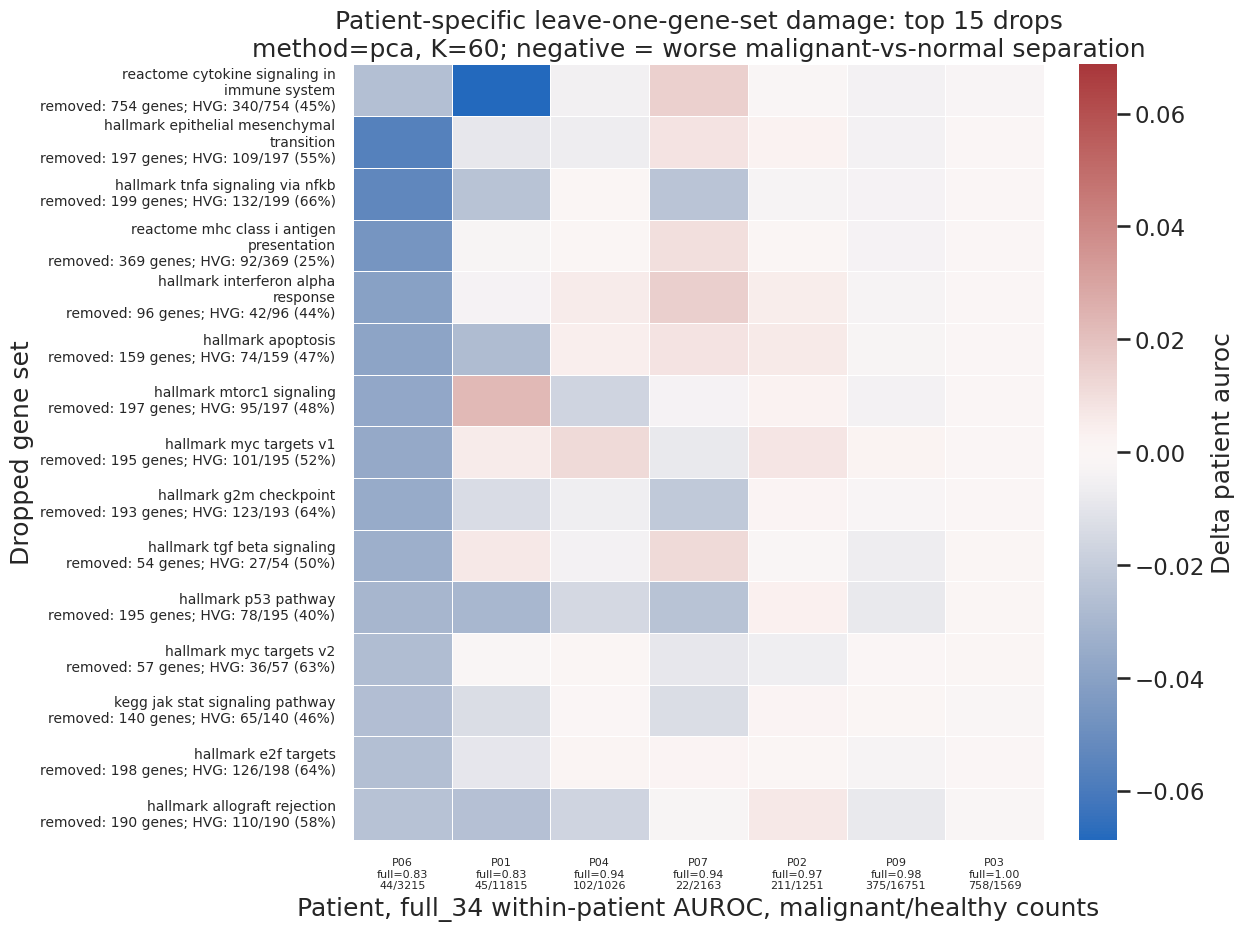

,panel_id,patient,method,k,auroc,full_34_patient_auroc,delta_patient_auroc,n_cells,n_malignant,n_normal,n_removed_genes,hvg_removed_fraction
231,drop_geneset__reactome_cytokine_signaling_in_i...,P01,pca,60,0.763940,0.832631,-0.068690,11860,45,11815,754,0.450928
60,drop_geneset__hallmark_epithelial_mesenchymal_...,P06,pca,60,0.768783,0.825477,-0.056694,3259,44,3215,197,0.553299
4,drop_geneset__hallmark_tnfa_signaling_via_nfkb,P06,pca,60,0.771900,0.825477,-0.053577,3259,44,3215,199,0.663317
186,drop_geneset__reactome_mhc_class_i_antigen_pre...,P06,pca,60,0.778870,0.825477,-0.046607,3259,44,3215,369,0.249322
193,drop_geneset__hallmark_interferon_alpha_response,P06,pca,60,0.785226,0.825477,-0.040252,3259,44,3215,96,0.437500
88,drop_geneset__hallmark_apoptosis,P06,pca,60,0.786526,0.825477,-0.038951,3259,44,3215,159,0.465409
123,drop_geneset__hallmark_mtorc1_signaling,P06,pca,60,0.788138,0.825477,-0.037339,3259,44,3215,197,0.482234
32,drop_geneset__hallmark_myc_targets_v1,P06,pca,60,0.789205,0.825477,-0.036272,3259,44,3215,195,0.517949
179,drop_geneset__hallmark_g2m_checkpoint,P06,pca,60,0.789658,0.825477,-0.035819,3259,44,3215,193,0.637306
214,drop_geneset__hallmark_tgf_beta_signaling,P06,pca,60,0.791743,0.825477,-0.033734,3259,44,3215,54,0.500000


In [9]:
# Reusable patient-specific malignant-vs-normal damage helpers for leave-one-gene-set ablations.
# These recompute per-patient AUROC from cached DR scores for a chosen method/K.

if "clean_panel_label" not in globals():
    import textwrap

    def clean_panel_label(panel_id: str, width: int = 30) -> str:
        label = str(panel_id)
        for prefix in ["drop_geneset__", "drop_group__", "redundancy_pruned__"]:
            label = label.replace(prefix, "")
        label = label.replace("_", " ")
        return "\n".join(textwrap.wrap(label, width=width))

if "symmetric_vmax" not in globals():
    def symmetric_vmax(values, floor: float = 0.01) -> float:
        arr = np.abs(np.asarray(values, dtype=float))
        finite = arr[np.isfinite(arr)]
        return max(float(finite.max()) if finite.size else floor, floor)


def per_patient_binary_auc_rows(
    scores: np.ndarray,
    obs_df: pd.DataFrame,
    min_cells: int = 50,
    min_class_cells: int = 10,
    max_folds: int = 5,
    random_state: int = 42,
) -> pd.DataFrame:
    """Compute within-patient malignant-vs-normal CV metrics from one score matrix."""
    mrd_mask = obs_df[TIMEPOINT_COL].astype(str).isin(MRD_VALUES)
    y = make_binary_labels(obs_df.loc[mrd_mask])
    if y.empty:
        return pd.DataFrame()

    X_binary = pd.DataFrame(scores[mrd_mask.to_numpy()], index=obs_df.index[mrd_mask]).loc[y.index]
    patient_series = obs_df.loc[y.index, PATIENT_COL].astype(str)
    rows = []
    for patient, idx in patient_series.groupby(patient_series).groups.items():
        idx = list(idx)
        Xp = X_binary.loc[idx]
        yp = y.loc[idx]
        class_counts = yp.value_counts()
        if len(idx) < min_cells or yp.nunique() < 2 or class_counts.min() < min_class_cells:
            continue
        n_splits = min(max_folds, int(class_counts.min()))
        if n_splits < 2:
            continue

        cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
        pred = pd.Series(index=Xp.index, dtype=float)
        for train_idx, test_idx in cv.split(Xp, yp):
            model = make_logreg_pipeline()
            model.fit(Xp.iloc[train_idx], yp.iloc[train_idx])
            pred.iloc[test_idx] = model.predict_proba(Xp.iloc[test_idx])[:, 1]

        rows.append(
            {
                "patient": patient,
                "auroc": roc_auc_score(yp, pred),
                "auprc": average_precision_score(yp, pred),
                "n_cells": len(idx),
                "n_malignant": int((yp == 1).sum()),
                "n_normal": int((yp == 0).sum()),
                "n_cv_folds": int(n_splits),
            }
        )
    return pd.DataFrame(rows)


def resolve_patient_heatmap_setting(
    leaderboard: pd.DataFrame,
    dr_method: str | None = None,
    k: int | None = None,
    score_col: str | None = None,
) -> tuple[str, int]:
    ok = leaderboard.loc[leaderboard["status"].eq("ok")].copy()
    full_controls = ok.loc[ok["panel_type"].eq("full_control")].copy()
    if full_controls.empty:
        raise ValueError("No full_34 control rows available.")
    if score_col is None:
        score_col = "metric_rank_score" if "metric_rank_score" in full_controls.columns else "triage_score"
    if dr_method is None or k is None:
        best_full = full_controls.sort_values(score_col, ascending=False).iloc[0]
        return str(best_full["method"]), int(best_full["k"])
    return str(dr_method), int(k)


def patient_delta_cache_path(
    out_dir: Path,
    dr_method: str,
    k: int,
    min_cells: int,
    min_class_cells: int,
    max_folds: int,
    random_state: int,
) -> Path:
    return (
        out_dir
        / f"leave_one_geneset_patient_delta_auroc_{dr_method}_k{k}_mincells{min_cells}"
        f"_minclass{min_class_cells}_folds{max_folds}_seed{random_state}.csv"
    )


def compute_leave_one_patient_delta_auc(
    leaderboard: pd.DataFrame,
    obs_df: pd.DataFrame,
    dr_method: str | None = None,
    k: int | None = None,
    *,
    out_dir: Path = OUT_DIR,
    score_col: str | None = None,
    min_cells: int = 50,
    min_class_cells: int = 10,
    max_folds: int = 5,
    random_state: int = 42,
    use_cache: bool = True,
    force_recompute: bool = False,
) -> tuple[pd.DataFrame, pd.DataFrame, str, int]:
    """Return per-patient ablation metrics and the selected leaderboard rows."""
    selected_method, selected_k = resolve_patient_heatmap_setting(leaderboard, dr_method, k, score_col)
    cache_path = patient_delta_cache_path(
        out_dir,
        selected_method,
        selected_k,
        min_cells,
        min_class_cells,
        max_folds,
        random_state,
    )
    if use_cache and cache_path.exists() and not force_recompute:
        patient_delta_df = pd.read_csv(cache_path)
        selected_rows = leaderboard.loc[
            leaderboard["status"].eq("ok")
            & leaderboard["method"].astype(str).eq(selected_method)
            & leaderboard["k"].astype(int).eq(selected_k)
            & leaderboard["panel_type"].isin(["full_control", "leave_one_geneset_out_strict_gene_ablation"])
        ].copy()
        return patient_delta_df, selected_rows, selected_method, selected_k

    selected_rows = leaderboard.loc[
        leaderboard["status"].eq("ok")
        & leaderboard["method"].astype(str).eq(selected_method)
        & leaderboard["k"].astype(int).eq(selected_k)
        & leaderboard["panel_type"].isin(["full_control", "leave_one_geneset_out_strict_gene_ablation"])
    ].copy()
    if selected_rows.empty or not selected_rows["panel_id"].eq("full_34").any():
        raise ValueError(f"No full_34/leave-one rows found for method={selected_method}, K={selected_k}.")

    per_patient_rows = []
    for _, row in selected_rows.iterrows():
        score_path = Path(row["score_source"])
        if not score_path.exists():
            print(f"Skipping missing score cache: {score_path}")
            continue
        scores = np.load(score_path)
        patient_metrics = per_patient_binary_auc_rows(
            scores,
            obs_df,
            min_cells=min_cells,
            min_class_cells=min_class_cells,
            max_folds=max_folds,
            random_state=random_state,
        )
        if patient_metrics.empty:
            continue
        for col in [
            "panel_id",
            "panel_type",
            "method",
            "k",
            "n_excluded_genes",
            "n_shared_genes_removed",
            "excluded_gene_sets",
            "score_source",
        ]:
            patient_metrics[col] = row.get(col)
        per_patient_rows.append(patient_metrics)

    if not per_patient_rows:
        raise ValueError("No per-patient AUROC rows could be computed.")

    per_patient_df = pd.concat(per_patient_rows, ignore_index=True)
    full_patient = (
        per_patient_df.loc[per_patient_df["panel_id"].eq("full_34"), ["patient", "auroc"]]
        .rename(columns={"auroc": "full_34_patient_auroc"})
    )
    patient_delta_df = per_patient_df.merge(full_patient, on="patient", how="left")
    patient_delta_df["delta_patient_auroc"] = patient_delta_df["auroc"] - patient_delta_df["full_34_patient_auroc"]
    patient_delta_df.to_csv(cache_path, index=False)
    print(f"Wrote {cache_path}")
    return patient_delta_df, selected_rows, selected_method, selected_k


def make_leave_one_patient_heatmap_data(
    patient_delta_df: pd.DataFrame,
    selected_rows: pd.DataFrame,
    *,
    value_col: str = "delta_patient_auroc",
    top_n: int | None = 15,
    label_width: int = 32,
    include_gene_metadata: bool = True,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Prepare heatmap matrix and annotated per-row table for plotting."""
    leave_one_delta = patient_delta_df.loc[
        patient_delta_df["panel_type"].eq("leave_one_geneset_out_strict_gene_ablation")
    ].copy()
    patient_panel_meta = add_ablation_gene_metadata(
        selected_rows.drop_duplicates("panel_id")
    ).loc[:, ["panel_id", "n_removed_genes", "hvg_removed_n", "hvg_removed_fraction"]]
    leave_one_delta = leave_one_delta.drop(
        columns=["n_removed_genes", "hvg_removed_n", "hvg_removed_fraction"],
        errors="ignore",
    ).merge(patient_panel_meta, on="panel_id", how="left")

    def patient_panel_label(row: pd.Series) -> str:
        label = clean_panel_label(row["panel_id"], width=label_width)
        if not include_gene_metadata:
            return label
        return (
            f"{label}\n"
            f"removed: {int(row['n_removed_genes'])} genes; "
            f"HVG: {int(row['hvg_removed_n'])}/{int(row['n_removed_genes'])} "
            f"({row['hvg_removed_fraction']:.0%})"
        )

    leave_one_delta["panel_label"] = leave_one_delta.apply(patient_panel_label, axis=1)
    panel_order = leave_one_delta.groupby("panel_label")[value_col].min().sort_values().index
    if top_n is not None:
        panel_order = panel_order[:top_n]

    heatmap_df = leave_one_delta.pivot_table(
        index="panel_label",
        columns="patient",
        values=value_col,
        aggfunc="mean",
    ).loc[panel_order]

    full_patient_auc = (
        patient_delta_df.loc[
            patient_delta_df["panel_id"].eq("full_34"),
            ["patient", "auroc", "n_malignant", "n_normal"],
        ]
        .drop_duplicates("patient")
        .sort_values("auroc")
    )
    patient_order = full_patient_auc["patient"].tolist()
    heatmap_df = heatmap_df[[p for p in patient_order if p in heatmap_df.columns]]
    heatmap_df = heatmap_df.rename(
        columns={
            row.patient: f"{row.patient}\nfull={row.auroc:.2f}\n{int(row.n_malignant)}/{int(row.n_normal)}"
            for row in full_patient_auc.itertuples()
        }
    )
    return heatmap_df, leave_one_delta


def plot_leave_one_patient_damage_heatmap(
    leaderboard: pd.DataFrame,
    obs_df: pd.DataFrame,
    dr_method: str | None = None,
    k: int | None = None,
    *,
    top_n: int | None = 15,
    value_col: str = "delta_patient_auroc",
    min_cells: int = 50,
    min_class_cells: int = 10,
    max_folds: int = 5,
    random_state: int = 42,
    label_width: int = 32,
    include_gene_metadata: bool = True,
    annotate: bool = False,
    cmap: str = "vlag",
    value_floor: float = 0.02,
    output_filename: str | None = None,
    use_cache: bool = True,
    force_recompute: bool = False,
    display_top_table: bool = True,
) -> dict[str, object]:
    """Compute and plot patient-specific leave-one-gene-set damage for one DR method/K."""
    patient_delta_df, selected_rows, selected_method, selected_k = compute_leave_one_patient_delta_auc(
        leaderboard,
        obs_df,
        dr_method=dr_method,
        k=k,
        min_cells=min_cells,
        min_class_cells=min_class_cells,
        max_folds=max_folds,
        random_state=random_state,
        use_cache=use_cache,
        force_recompute=force_recompute,
    )
    heatmap_df, leave_one_delta = make_leave_one_patient_heatmap_data(
        patient_delta_df,
        selected_rows,
        value_col=value_col,
        top_n=top_n,
        label_width=label_width,
        include_gene_metadata=include_gene_metadata,
    )

    fig_height = max(6, 0.48 * len(heatmap_df) + 2)
    fig_width = max(9, 1.05 * heatmap_df.shape[1] + 5)
    fig, ax = plt.subplots(figsize=(fig_width, fig_height), constrained_layout=True)
    vmax = symmetric_vmax(heatmap_df.to_numpy(), floor=value_floor)
    sns.heatmap(
        heatmap_df,
        cmap=cmap,
        center=0,
        vmin=-vmax,
        vmax=vmax,
        annot=annotate,
        fmt=".2f",
        annot_kws={"fontsize": 8},
        linewidths=0.7,
        linecolor="white",
        cbar_kws={"label": value_col.replace("_", " ").replace("delta patient", "Delta patient")},
        ax=ax,
    )
    n_label = len(heatmap_df) if top_n is not None else "all"
    ax.set_title(
        f"Patient-specific leave-one-gene-set damage: top {n_label} drops\n"
        f"method={selected_method}, K={selected_k}; negative = worse malignant-vs-normal separation"
    )
    ax.set_xlabel("Patient, full_34 within-patient AUROC, malignant/healthy counts")
    ax.set_ylabel("Dropped gene set")
    ax.tick_params(axis="x", rotation=0, labelsize=8)
    ax.tick_params(axis="y", labelsize=10)

    if output_filename is None:
        output_filename = f"leave_one_geneset_patient_delta_auroc_heatmap_{selected_method}_k{selected_k}.png"
    out_path = OUT_DIR / output_filename
    fig.savefig(out_path, dpi=200, bbox_inches="tight")
    print(f"Saved {out_path}")
    plt.show()

    if display_top_table:
        display(
            leave_one_delta.sort_values(value_col)[[
                "panel_id",
                "patient",
                "method",
                "k",
                "auroc",
                "full_34_patient_auroc",
                value_col,
                "n_cells",
                "n_malignant",
                "n_normal",
                "n_removed_genes",
                "hvg_removed_fraction",
            ]].head(20)
        )

    return {
        "patient_delta_df": patient_delta_df,
        "leave_one_patient_delta": leave_one_delta,
        "heatmap_df": heatmap_df,
        "selected_rows": selected_rows,
        "method": selected_method,
        "k": selected_k,
        "fig": fig,
        "ax": ax,
    }


patient_damage_result = plot_leave_one_patient_damage_heatmap(
    leaderboard_df,
    obs,
    dr_method=None,  # set e.g. "pca", "fa", or "factosig" to override
    k=None,          # set e.g. 20, 40, or 60 to override
    top_n=15,
    min_cells=50,
    min_class_cells=10,
    max_folds=5,
    random_state=42,
    annotate=False,
    force_recompute=False,
)

Saved /home/minhang/mds_project/sc_classification/experiments/20260401_023024_plan0_k_sweep_60_none_all_filtered_8f5363e0/analysis/old_geneset_pruning_metrics/leave_one_geneset_patient_delta_auroc_heatmap_fa_k60.png


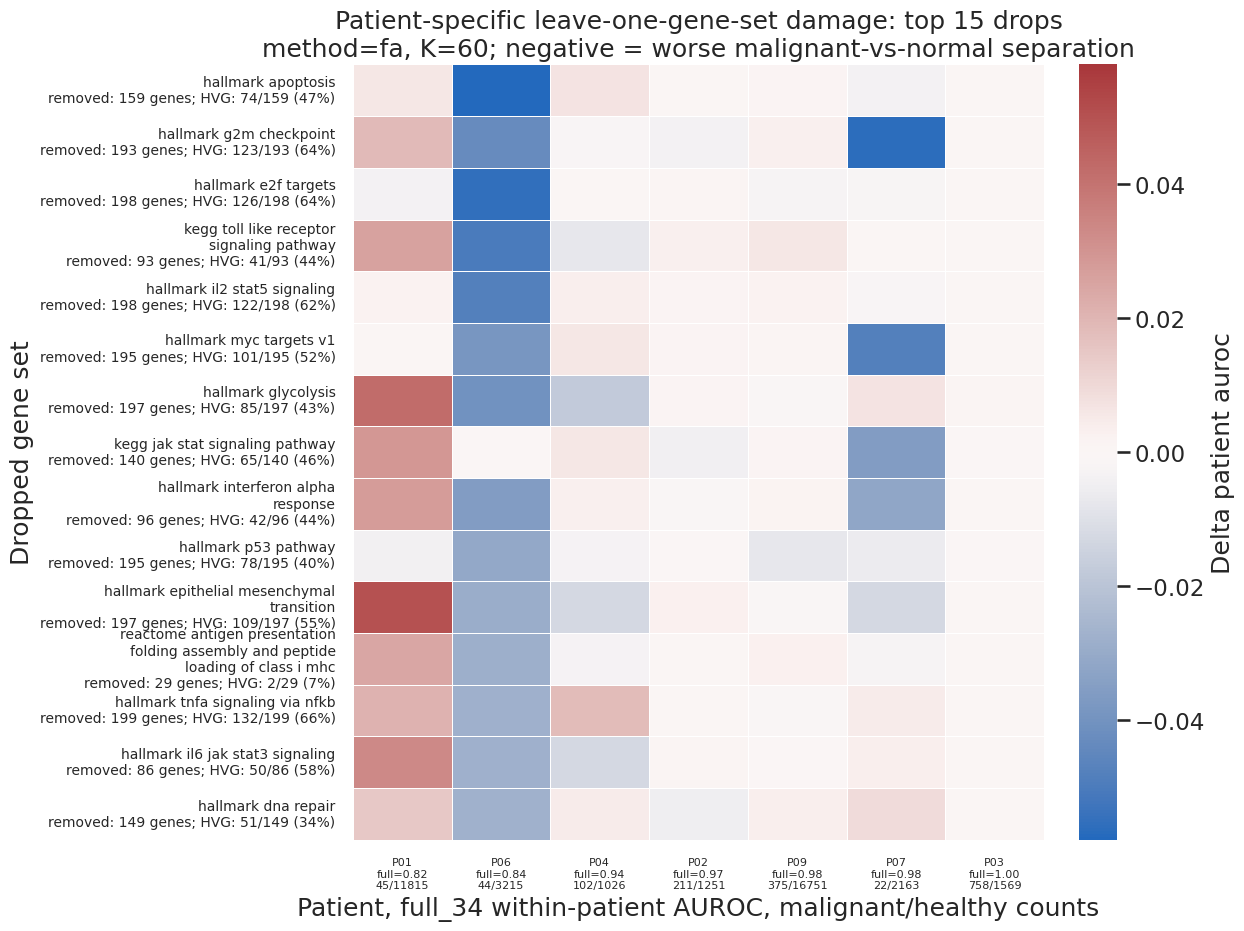

,panel_id,patient,method,k,auroc,full_34_patient_auroc,delta_patient_auroc,n_cells,n_malignant,n_normal,n_removed_genes,hvg_removed_fraction
74,drop_geneset__hallmark_apoptosis,P06,fa,60,0.786357,0.844239,-0.057882,3259,44,3215,159,0.465409
159,drop_geneset__hallmark_g2m_checkpoint,P07,fa,60,0.925587,0.981885,-0.056298,2185,22,2163,193,0.637306
102,drop_geneset__hallmark_e2f_targets,P06,fa,60,0.788682,0.844239,-0.055556,3259,44,3215,198,0.636364
53,drop_geneset__kegg_toll_like_receptor_signalin...,P06,fa,60,0.793765,0.844239,-0.050474,3259,44,3215,93,0.440860
144,drop_geneset__hallmark_il2_stat5_signaling,P06,fa,60,0.796070,0.844239,-0.048169,3259,44,3215,198,0.616162
47,drop_geneset__hallmark_myc_targets_v1,P07,fa,60,0.933930,0.981885,-0.047955,2185,22,2163,195,0.517949
158,drop_geneset__hallmark_g2m_checkpoint,P06,fa,60,0.800891,0.844239,-0.043348,3259,44,3215,193,0.637306
193,drop_geneset__hallmark_glycolysis,P06,fa,60,0.803930,0.844239,-0.040308,3259,44,3215,197,0.431472
46,drop_geneset__hallmark_myc_targets_v1,P06,fa,60,0.805380,0.844239,-0.038859,3259,44,3215,195,0.517949
201,drop_geneset__kegg_jak_stat_signaling_pathway,P07,fa,60,0.945803,0.981885,-0.036082,2185,22,2163,140,0.464286


In [10]:
patient_damage_result = plot_leave_one_patient_damage_heatmap(
    leaderboard_df,
    obs,
    dr_method="fa",  # set e.g. "pca", "fa", or "factosig" to override
    k=60,          # set e.g. 20, 40, or 60 to override
    top_n=15,
    min_cells=50,
    min_class_cells=10,
    max_folds=5,
    random_state=42,
    annotate=False,
    force_recompute=False,
)

Saved /home/minhang/mds_project/sc_classification/experiments/20260401_023024_plan0_k_sweep_60_none_all_filtered_8f5363e0/analysis/old_geneset_pruning_metrics/leave_one_geneset_patient_delta_auroc_heatmap_factosig_k60.png


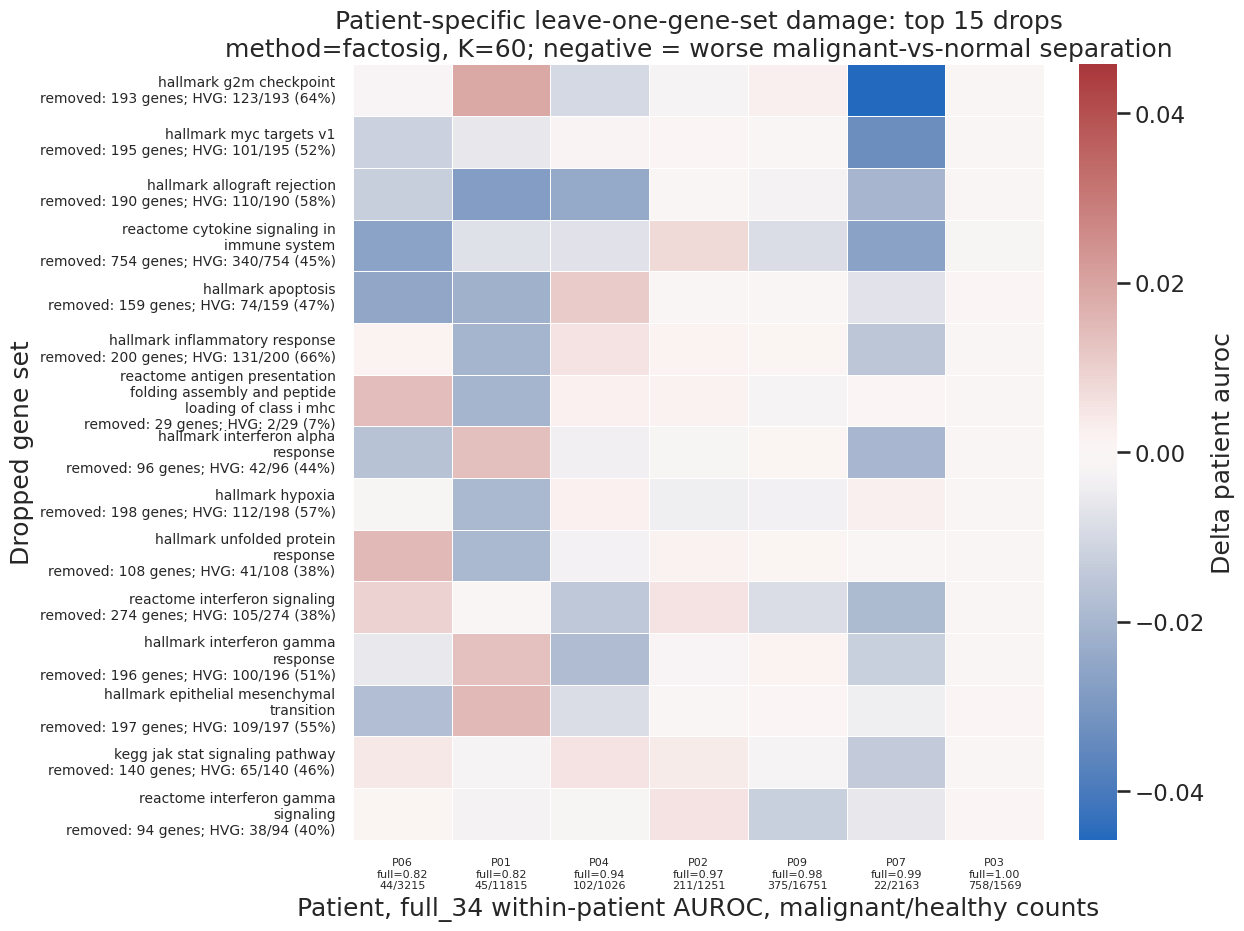

,panel_id,patient,method,k,auroc,full_34_patient_auroc,delta_patient_auroc,n_cells,n_malignant,n_normal,n_removed_genes,hvg_removed_fraction
96,drop_geneset__hallmark_g2m_checkpoint,P07,factosig,60,0.940613,0.986320,-0.045707,2185,22,2163,193,0.637306
61,drop_geneset__hallmark_myc_targets_v1,P07,factosig,60,0.953158,0.986320,-0.033161,2185,22,2163,195,0.517949
224,drop_geneset__hallmark_allograft_rejection,P01,factosig,60,0.796795,0.824733,-0.027938,11860,45,11815,190,0.578947
236,drop_geneset__reactome_cytokine_signaling_in_i...,P07,factosig,60,0.959631,0.986320,-0.026689,2185,22,2163,754,0.450928
235,drop_geneset__reactome_cytokine_signaling_in_i...,P06,factosig,60,0.793836,0.819984,-0.026149,3259,44,3215,754,0.450928
53,drop_geneset__hallmark_apoptosis,P06,factosig,60,0.795073,0.819984,-0.024912,3259,44,3215,159,0.465409
227,drop_geneset__hallmark_allograft_rejection,P04,factosig,60,0.915635,0.939609,-0.023975,1128,102,1026,190,0.578947
49,drop_geneset__hallmark_apoptosis,P01,factosig,60,0.802983,0.824733,-0.021750,11860,45,11815,159,0.465409
203,drop_geneset__hallmark_inflammatory_response,P01,factosig,60,0.804145,0.824733,-0.020588,11860,45,11815,200,0.655000
7,drop_geneset__reactome_antigen_presentation_fo...,P01,factosig,60,0.804239,0.824733,-0.020494,11860,45,11815,29,0.068966


In [11]:
patient_damage_result = plot_leave_one_patient_damage_heatmap(
    leaderboard_df,
    obs,
    dr_method="factosig",  # set e.g. "pca", "fa", or "factosig" to override
    k=60,          # set e.g. 20, 40, or 60 to override
    top_n=15,
    min_cells=50,
    min_class_cells=10,
    max_folds=5,
    random_state=42,
    annotate=False,
    force_recompute=False,
)

## 5. Quantitative Gate for UMAPs

UMAPs are generated only after a panel passes metric gates against the full 34-set control at the same method/K. This keeps visualization focused on panels that are quantitatively competitive and smaller or more interpretable.

In [12]:
if not UMAP_SELECTION_PATH.exists():
    raise FileNotFoundError(
        f"Missing {UMAP_SELECTION_PATH}. Run the external script to generate quantitative UMAP gates."
    )

umap_selection_df = pd.read_csv(UMAP_SELECTION_PATH)
print("Selected UMAP rows:", len(umap_selection_df))
selection_cols = [
    "panel_id",
    "panel_type",
    "method",
    "k",
    "n_gene_sets",
    "n_genes",
    "gene_fraction_vs_full",
    "across_patient_auroc",
    "knn_label_purity_macro",
    "pseudotime_knn_smoothness",
    "triage_score",
]
selection_cols = [c for c in selection_cols if c in umap_selection_df.columns]
display(umap_selection_df[selection_cols])

Selected UMAP rows: 15


,panel_id,panel_type,method,k,n_gene_sets,n_genes,gene_fraction_vs_full,across_patient_auroc,knn_label_purity_macro,pseudotime_knn_smoothness,triage_score
0,full_34,full_control,pca,40,34,3233,1.000000,0.846835,0.784882,0.799208,0.703283
1,full_34,full_control,pca,60,34,3233,1.000000,0.860255,0.782861,0.798084,0.792929
2,full_34,full_control,fa,40,34,3233,1.000000,0.859415,0.782741,0.781041,0.599747
3,drop_geneset__reactome_mhc_class_i_antigen_pre...,leave_one_geneset_out_strict_gene_ablation,pca,40,33,2864,0.885865,0.858751,0.784311,0.798206,0.846034
4,drop_geneset__hallmark_g2m_checkpoint,leave_one_geneset_out_strict_gene_ablation,pca,40,33,3040,0.940303,0.856121,0.785315,0.799952,0.845444
5,drop_geneset__reactome_interferon_signaling,leave_one_geneset_out_strict_gene_ablation,pca,40,33,2959,0.915249,0.855809,0.786544,0.799135,0.822056
6,drop_geneset__hallmark_e2f_targets,leave_one_geneset_out_strict_gene_ablation,pca,40,33,3035,0.938757,0.852743,0.786987,0.800768,0.814111
7,drop_group__tgf_plasticity,group_dropout_strict_gene_ablation,pca,40,32,2987,0.923910,0.864219,0.780899,0.796507,0.813181
8,drop_geneset__hallmark_tnfa_signaling_via_nfkb,leave_one_geneset_out_strict_gene_ablation,pca,60,33,3034,0.938447,0.864402,0.781163,0.796063,0.792061
9,drop_geneset__hallmark_myc_targets_v1,leave_one_geneset_out_strict_gene_ablation,pca,40,33,3038,0.939685,0.852789,0.786266,0.800232,0.787456


In [13]:
umap_pngs = sorted(UMAP_DIR.glob("*.png"))
print(f"Found {len(umap_pngs)} gated UMAP PNGs in {UMAP_DIR}")
if not umap_pngs:
    print("To generate gated UMAP PNGs, run the external script with --make-umaps.")
else:
    umap_files_df = pd.DataFrame({"umap_png": [str(p) for p in umap_pngs]})
    display(umap_files_df)

Found 0 gated UMAP PNGs in /home/minhang/mds_project/sc_classification/experiments/20260401_023024_plan0_k_sweep_60_none_all_filtered_8f5363e0/analysis/old_geneset_pruning_metrics/umaps
To generate gated UMAP PNGs, run the external script with --make-umaps.


## 6. Recommendation Template

After running the grid, use the saved outputs to summarize:

- **Essential candidates:** leave-one-out drops that reduce malignant-vs-healthy, cell-type, or pseudotime metrics.
- **Redundant candidates:** leave-one-out drops with negligible metric loss, especially if they have high covered-gene overlap with retained sets.
- **Potentially harmful candidates:** leave-one-out drops that improve multiple metrics.
- **Recommended pruned panel:** smallest panel that preserves the full-control metric profile and remains biologically interpretable.

Key output files:

- `metadata_contract.csv`
- `geneset_coverage.csv`
- `panel_manifest.csv`
- `redundancy_pruning_decisions.csv`
- `panel_dr_metric_rows.csv`
- `panel_dr_leaderboard.csv`
- `umap_selection.csv`
- `leaderboard_metric_summary.png`
- gated UMAP PNGs in `umaps/`